# Amazon Music Clustering

## Problem Statement

Amazon Music contains thousands of songs with different audio characteristics.

The objective of this project is to automatically group similar songs using clustering techniques based on their audio features such as danceability, energy, loudness, acousticness, tempo, and valence.

This project uses Unsupervised Machine Learning to discover hidden patterns in music data and identify similar song groups.

### Importing Libraries:

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
pd.set_option('display.max_columns', None)
print('Libraries Imported Successfully')

Libraries Imported Successfully


### Dataset Loading and Initial Inspection

In this section, the dataset is loaded and examined to understand its structure, dimensions, and available features.

The objective is to gain a preliminary understanding of the data before performing data quality checks and exploratory data analysis.

In [4]:
df=pd.read_csv(r"C:\Users\hp\Desktop\PROJECTS\Project_4\data\single_genre_artists.csv")

In [5]:
df.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,-13.757,1,0.0512,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,-15.375,1,0.0670,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,-15.514,1,0.0592,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,-12.393,0,0.1650,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,-13.806,1,0.1380,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [6]:
df.tail()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
95832,44r4zta6P9flkhKaVnbsvG,Freaks,70,174800,0,14Y3trk7LaslSFTk1G35rx,2019-02-25,0.674,0.5680,1,-6.356,1,0.0408,0.116,0.000,0.1650,0.640,166.107,4,16057.0,['alt z'],Jordan Clarke,56
95833,0MmaEacabpK8Yp3Mdeo5uY,下雨天,50,265846,0,5VGgFE9nPgMfEnYiPT5J2B,2020-02-25,0.528,0.6730,4,-3.639,1,0.0314,0.143,0.000,0.0989,0.297,130.066,4,929.0,['chinese viral pop'],芝麻,36
95834,1dKxf4Ht2SsKLyXfSDJAgy,The Cutest Puppy,67,82500,0,7vgGpuiXdNlCmc994PlMlz,2020-10-30,0.609,0.0172,8,-28.573,1,0.1180,0.996,0.973,0.1080,0.890,68.619,4,23.0,['instrumental lullaby'],Laureen Conrad,52
95835,0SjsIzJkZfDU7wlcdklEFR,John Brown's Song,66,185250,0,4MxqhahGRT4BPz1PilXGeu,2020-03-20,0.562,0.0331,1,-25.551,1,0.1030,0.996,0.961,0.1110,0.386,63.696,3,91.0,['instrumental lullaby'],Gregory Oberle,55
95836,5rgu12WBIHQtvej2MdHSH0,云与海,50,258267,0,1QLBXKM5GCpyQQSVMNZqrZ,2020-09-26,0.560,0.5180,0,-7.471,0,0.0292,0.785,0.000,0.0648,0.211,131.896,4,896.0,['chinese viral pop'],阿YueYue,38


In [7]:
df.shape

(95837, 23)

In [8]:
df.sample(5)

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
62027,4Rkg6OrpJd62L8cCfg7Uzr,Pojď Mě Líbat,8,260020,0,0JaI0aAFEFfEcFk5mLAFbP,1990,0.617,0.831,11,-11.284,0,0.0579,0.0265,0.009960,0.330,0.702,108.214,4,5788.0,['classic czech pop'],Petr Kotvald,41
42216,3mur0saDbivMWj69vdaUCf,Is She My Girl Friend?,0,206180,0,53E8i8Zawt25O5bICAORNO,1932,0.700,0.456,5,-7.690,1,0.0421,0.9880,0.367000,0.119,0.815,111.617,4,258.0,['vintage jazz'],Coon-Sanders' Original Nighthawk Orchestra,8
40190,4b2S0Ahh3urlsR59O6jlhz,004 - als Retter in der Not - Teil 39,28,68960,0,1hD52edfn6aNsK3fb5c2OT,1978-11-04,0.678,0.515,7,-10.421,1,0.9530,0.6640,0.000000,0.550,0.687,67.390,3,84951.0,['hoerspiel'],Fünf Freunde,73
58206,5Wrl4uc9SjC8ZnAimiMtys,Przekorny Los,46,196453,0,10wjV72OetIdsUQEcjSnOd,2015-10-10,0.853,0.919,7,-6.337,1,0.0428,0.0763,0.000032,0.047,0.825,132.034,4,31913.0,['disco polo'],Akcent,47
82572,5n1sr4SYpPHgmERVXNxQMw,Onoare,35,236975,0,4cHSmQfdi8CMDQbHjlHK72,2013-01-30,0.488,0.916,5,-4.918,0,0.1600,0.2250,0.000000,0.248,0.503,126.209,5,16736.0,['romanian rap'],Guesswho,35


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  str    
 1   name_song           95837 non-null  str    
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  str    
 6   release_date        95837 non-null  str    
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  valence        

# Data Quality Assessment

In [10]:
df.isnull().sum().sum()

np.int64(0)

## Observation

- No missing values were found in the dataset.
- Every feature contains complete information.
- Data imputation techniques are not required.
- The dataset is ready for further analysis without missing value treatment.

### Checking Duplicacy records:

In [11]:
df.duplicated().sum()

np.int64(0)

## Duplicate Record Analysis

No duplicate records were found in the dataset.

Therefore, no duplicate removal was required before clustering.

### Checking for Statistical functions:

## Statistical Summary Analysis

The statistical summary provides information about the central tendency, spread, and distribution of numerical features.

This analysis helps identify:

- Feature ranges
- Potential outliers
- Scaling requirements
- Feature suitability for clustering

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
popularity_songs,95837.0,26.066394,16.254133,0.00000,13.0000,26.000000,37.0000,9.800000e+01
duration_ms,95837.0,208732.031835,117752.555950,6373.00000,157333.0000,204000.000000,250267.0000,4.800118e+06
explicit,95837.0,0.029644,0.169604,0.00000,0.0000,0.000000,0.0000,1.000000e+00
danceability,95837.0,0.586853,0.155422,0.00000,0.4880,0.605000,0.7000,9.910000e-01
energy,95837.0,0.541083,0.236304,0.00002,0.3650,0.542000,0.7270,1.000000e+00
key,95837.0,5.196782,3.534923,0.00000,2.0000,5.000000,8.0000,1.100000e+01
loudness,95837.0,-10.157862,4.748798,-50.17400,-12.7230,-9.397000,-6.6920,5.376000e+00
mode,95837.0,0.648069,0.477575,0.00000,0.0000,1.000000,1.0000,1.000000e+00
speechiness,95837.0,0.168832,0.275417,0.00000,0.0341,0.046200,0.1030,9.680000e-01
acousticness,95837.0,0.458989,0.330416,0.00000,0.1330,0.453000,0.7590,9.960000e-01


## Observation

### Dataset Size

- The dataset contains 95,837 songs.
- Statistical information is available for all numerical features.

### Song Characteristics

- Average danceability is 0.59, indicating that most songs are moderately dance-friendly.
- Average energy is 0.54, suggesting a balanced mix of energetic and calm songs.
- Average valence is 0.57, indicating generally positive musical moods.

### Tempo Analysis

- Average tempo is approximately 118 BPM.
- Tempo ranges from 0 to 239 BPM, showing high variation across songs.

### Duration Analysis

- Average song duration is 208,732 milliseconds (~3.48 minutes).
- Maximum duration is approximately 4.8 million milliseconds (~80 minutes).
- This indicates the presence of extremely long tracks and potential outliers.

### Loudness Analysis

- Average loudness is -10.16 dB.
- Loudness varies significantly across songs, indicating differences in recording intensity.

### Artist Popularity and Followers

- Artist followers show extremely high variation.
- Maximum followers exceed 28 million.
- Significant outliers are expected in the followers feature.

### Clustering Perspective

- Numerical features are measured on different scales.
- Feature scaling will be mandatory before applying clustering algorithms.

# Feature Categorization

Before performing exploratory data analysis, the dataset features are categorized into numerical and categorical variables.

This helps in selecting appropriate visualization and preprocessing techniques for each feature type.

In [13]:
num_cols=df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['popularity_songs', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'followers', 'popularity_artists'],
      dtype='str')

In [14]:
cat_cols=df.select_dtypes(include=['object']).columns
cat_cols

Index(['id_songs', 'name_song', 'id_artists', 'release_date', 'genres',
       'name_artists'],
      dtype='str')

In [15]:
print("Number of Numerical Columns :", len(num_cols))
print("Number of Categorical Columns :", len(cat_cols))

Number of Numerical Columns : 17
Number of Categorical Columns : 6


## Observation

- The dataset contains a total of **23 features**.
- Out of these, **17 are numerical features** and **6 are categorical features**.
- Numerical features include song characteristics such as danceability, energy, loudness, speechiness, acousticness, tempo, and popularity metrics.
- Categorical features contain song identifiers, artist identifiers, artist names, song names, genre information, and release dates.
- Since clustering algorithms work on numerical data, the numerical features will be the primary focus during the clustering process.
- Categorical features will mainly be used for interpretation and cluster profiling after model development.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution and behavior of numerical features.

The objective is to identify:

- Distribution patterns
- Feature ranges
- Skewness
- Outliers
- Data characteristics before clustering

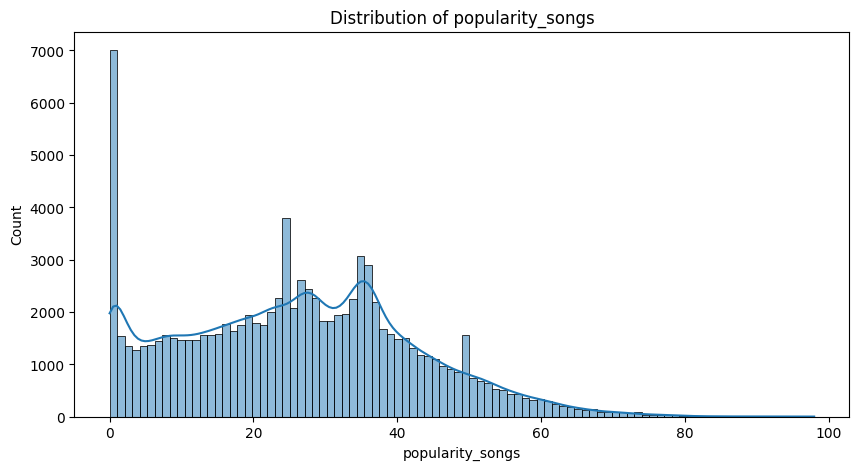

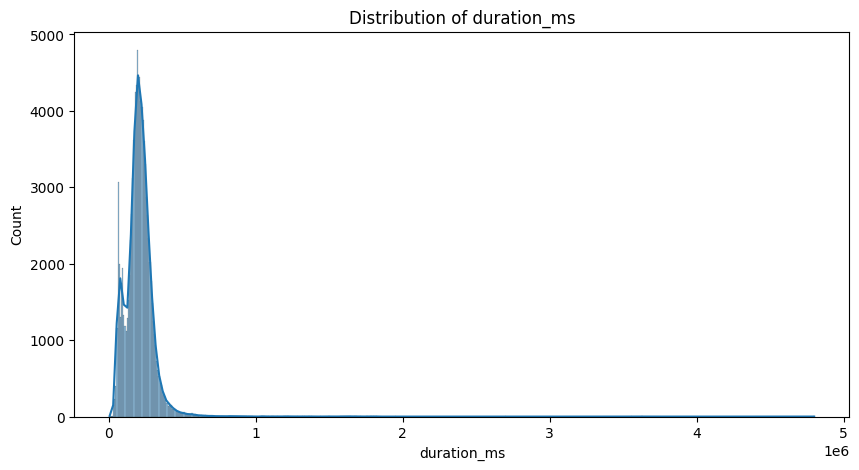

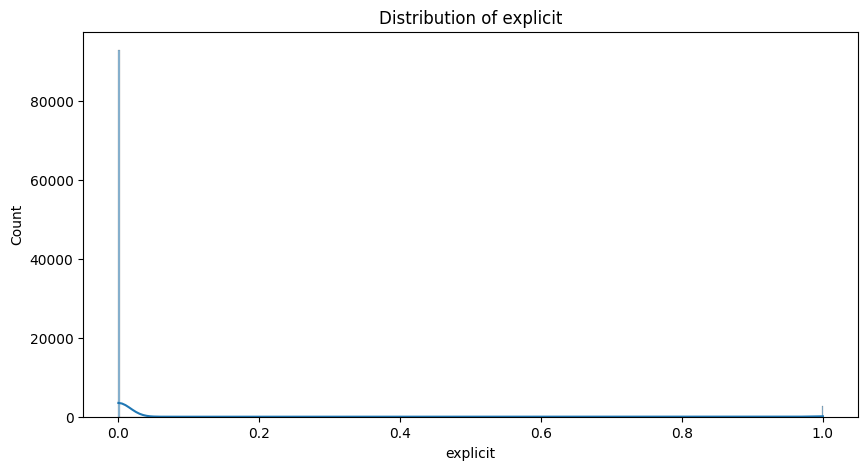

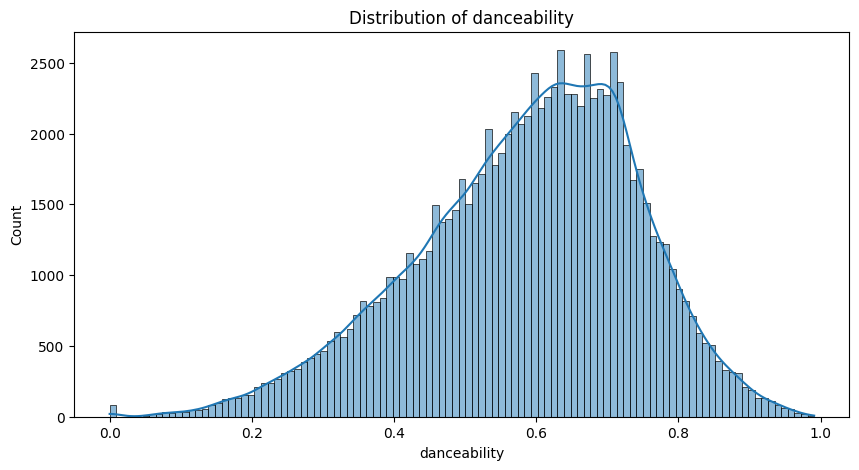

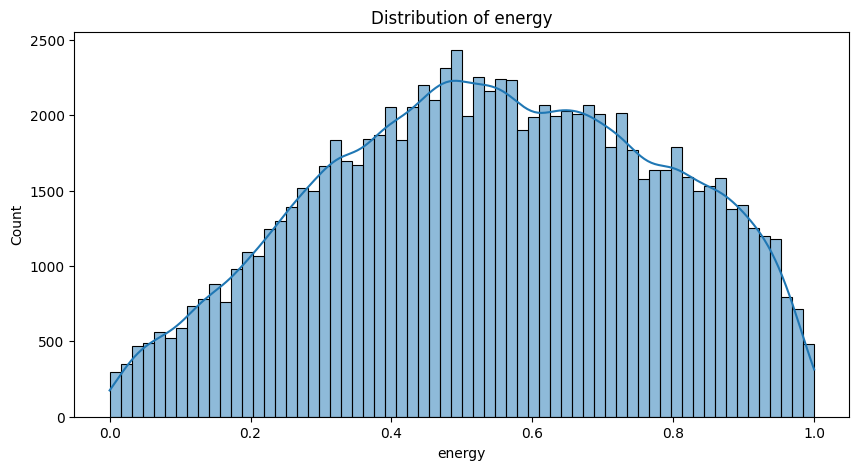

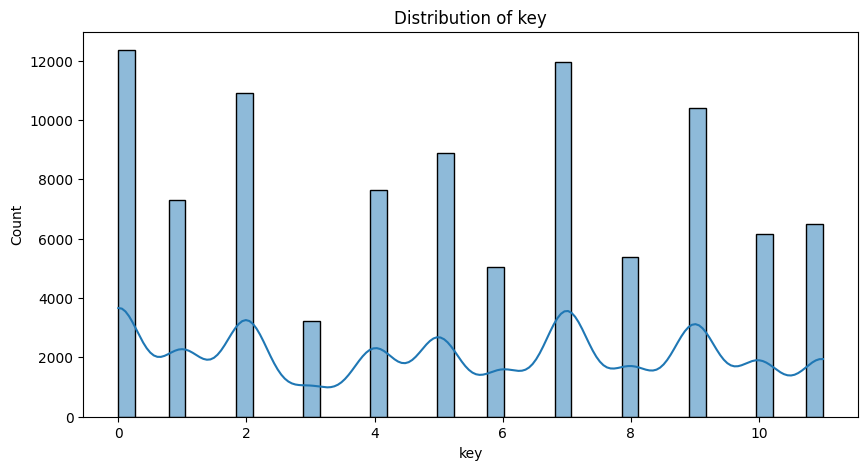

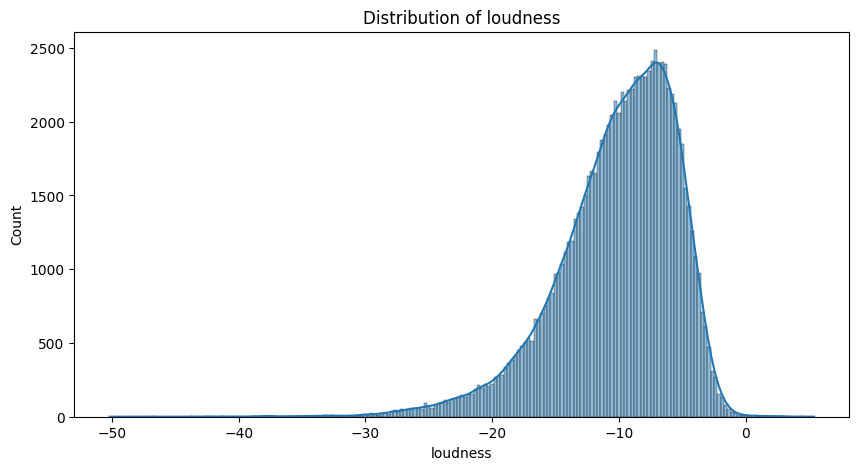

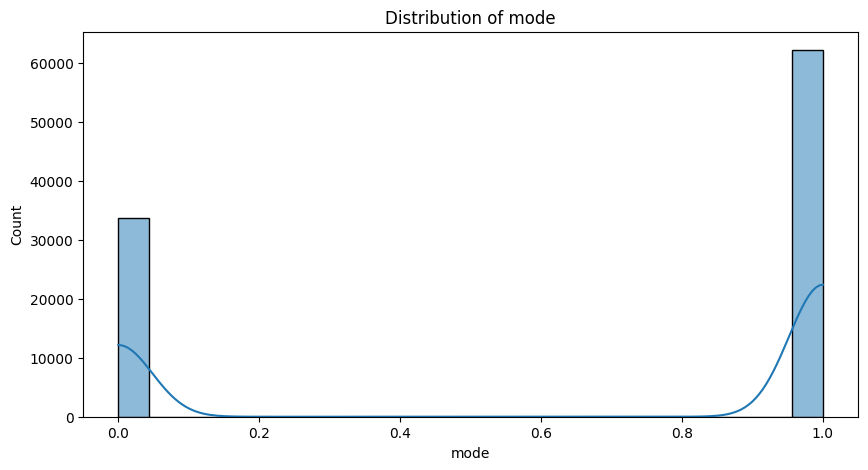

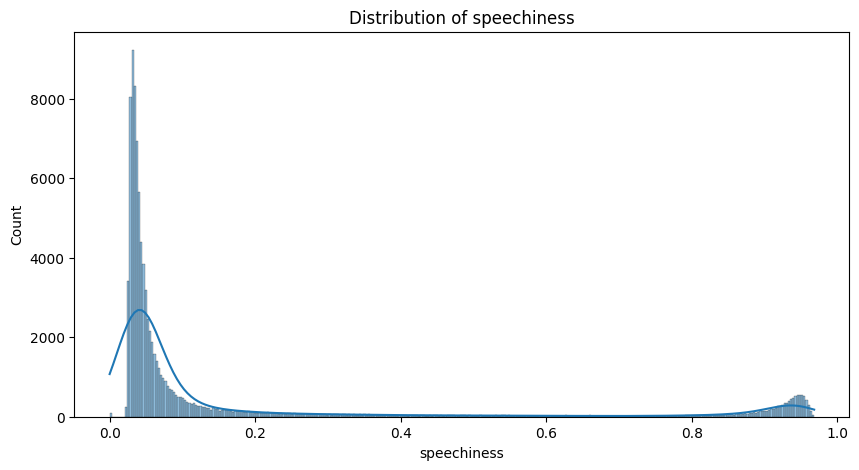

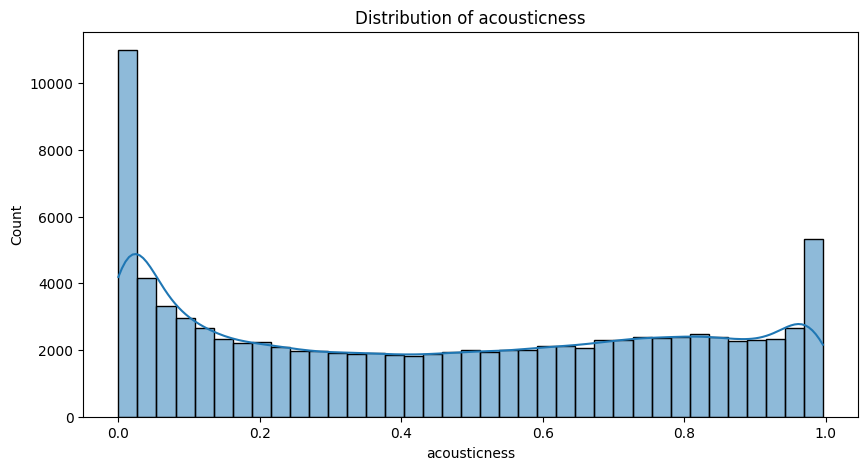

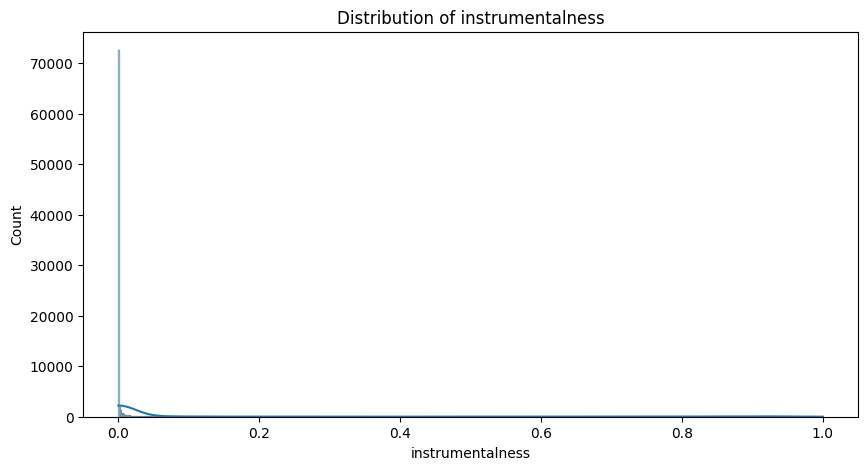

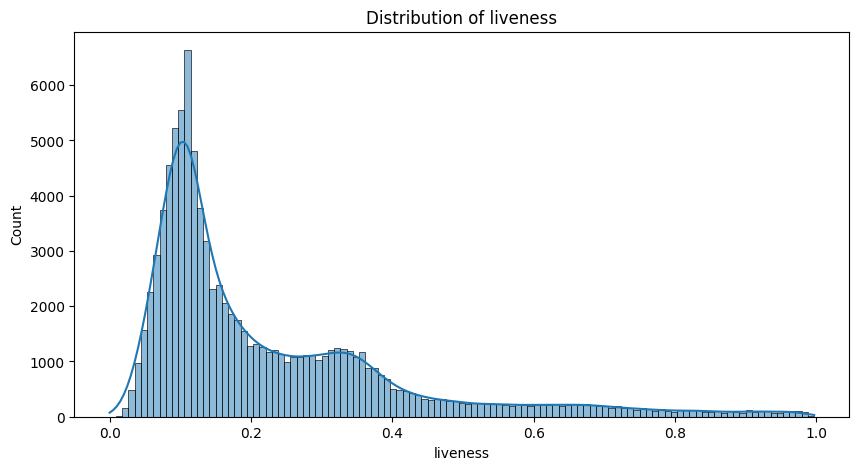

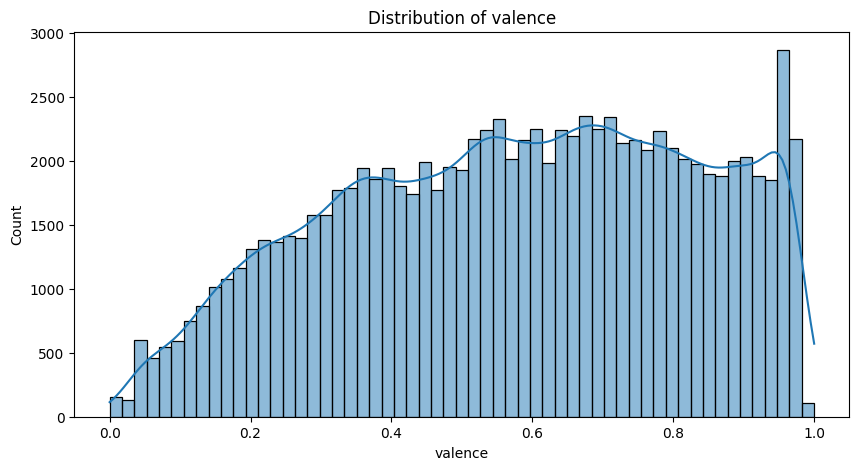

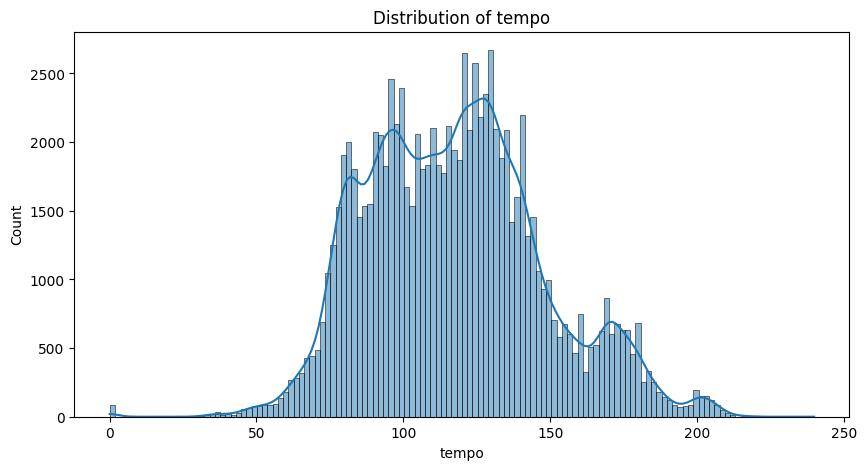

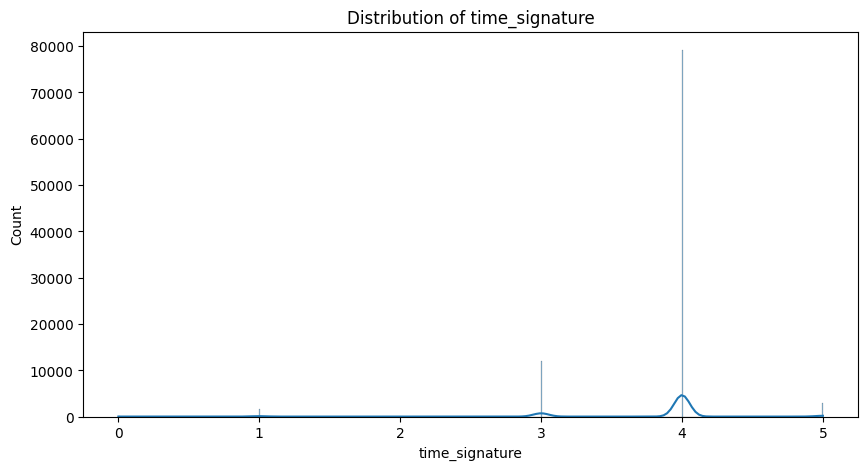

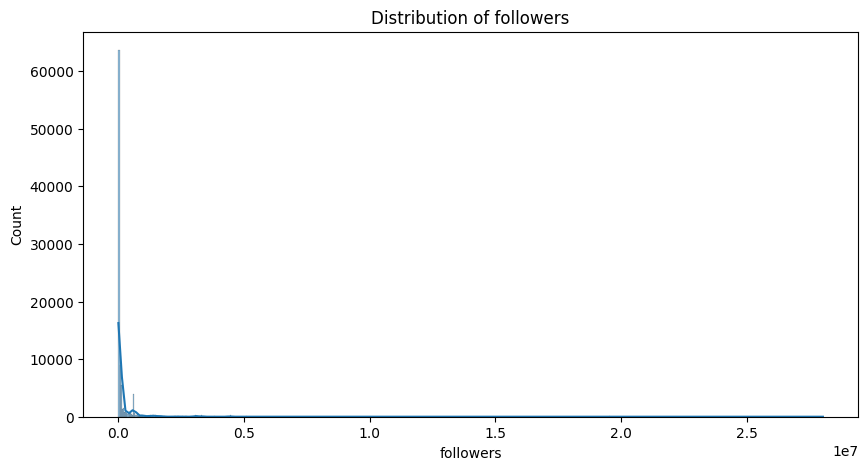

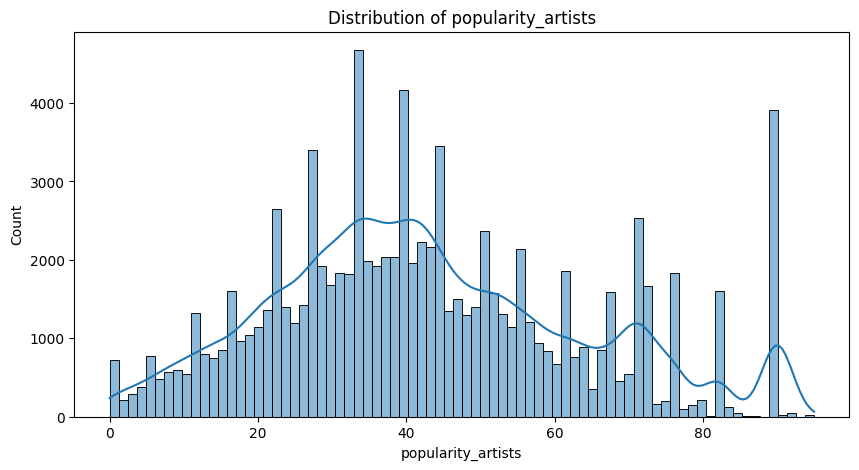

In [16]:
for col in num_cols:

    plt.figure(figsize=(10,5))

    sns.histplot(df[col], kde=True)

    plt.title(f"Distribution of {col}")

    plt.show()

## Observation

### Popularity Songs
- Song popularity shows a non-normal distribution.
- Most songs have popularity between 20 and 40.
- Very high popularity songs are relatively rare.

### Duration
- Duration is highly right-skewed.
- Most songs are concentrated around 2–4 minutes.
- Few songs have extremely long durations.

### Explicit
- Majority of songs are non-explicit.
- Explicit songs represent a very small portion of the dataset.

### Danceability
- Danceability follows an approximately bell-shaped distribution.
- Most songs have medium to high danceability scores.

### Energy
- Energy is reasonably distributed across the range.
- Most songs exhibit moderate energy levels.

### Loudness
- Loudness shows a near-normal distribution.
- Majority of songs fall between -15 dB and -5 dB.

### Speechiness
- Highly right-skewed distribution.
- Most songs contain very little spoken content.

### Acousticness
- Distribution is spread across the entire range.
- Both highly acoustic and non-acoustic songs exist.

### Instrumentalness
- Extremely right-skewed distribution.
- Most songs contain vocals rather than being instrumental.

### Liveness
- Right-skewed distribution.
- Majority of songs have low live-performance characteristics.

### Valence
- Fairly balanced distribution.
- Dataset contains both positive and negative mood songs.

### Tempo
- Multi-modal distribution.
- Most songs lie between 80 and 150 BPM.

### Time Signature
- Majority of songs use 4/4 time signature.
- Other signatures occur very infrequently.

### Followers
- Extremely right-skewed distribution.
- Few artists have exceptionally large follower counts.

### Popularity Artists
- Most artists have moderate popularity.
- Very highly popular artists are limited in number.

### Boxplot Analysis :

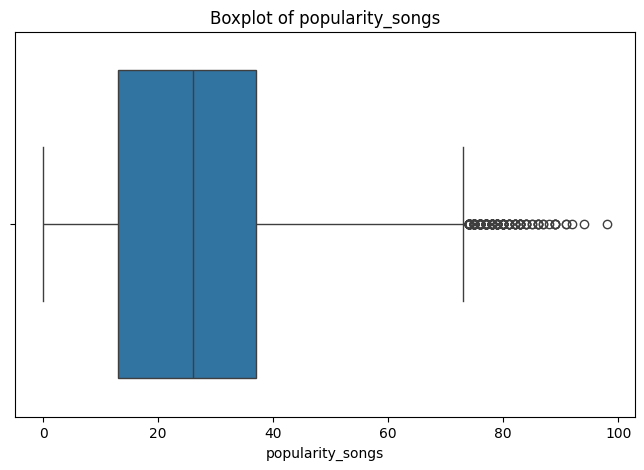

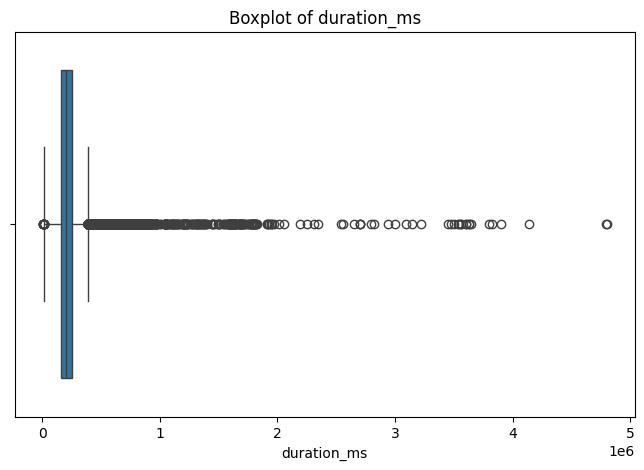

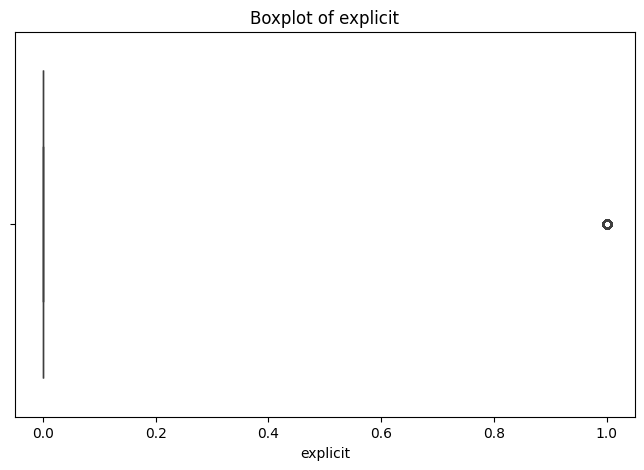

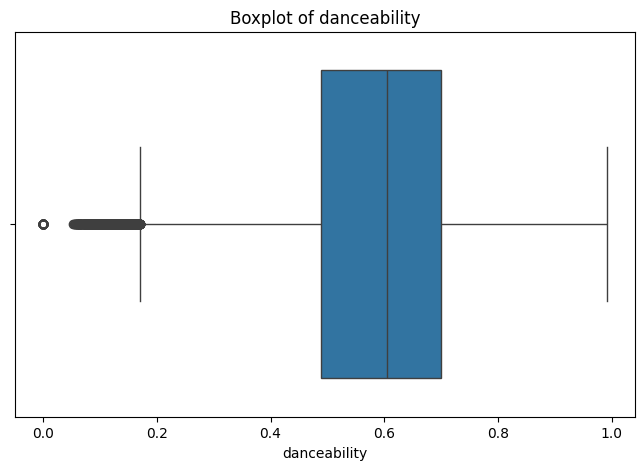

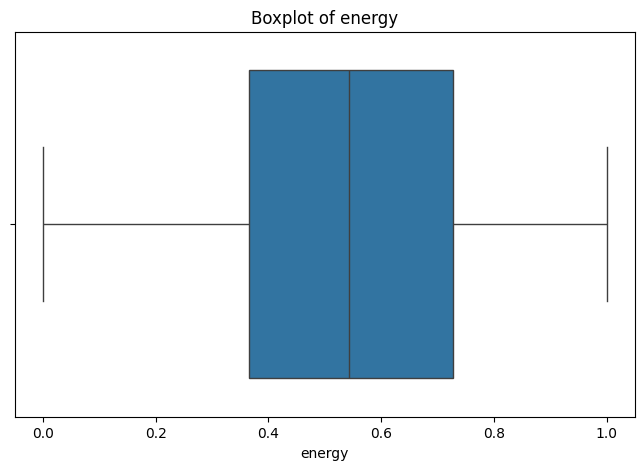

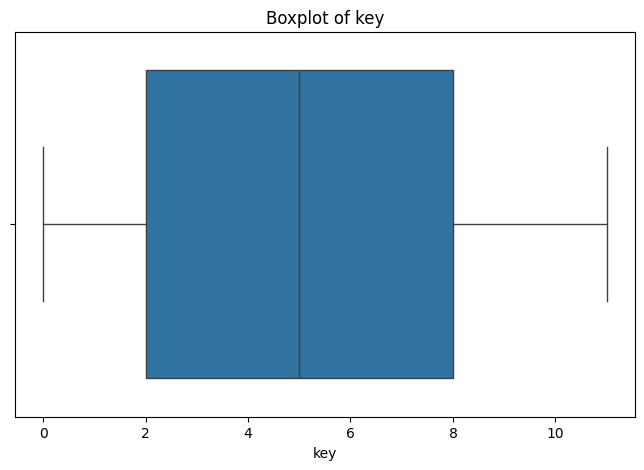

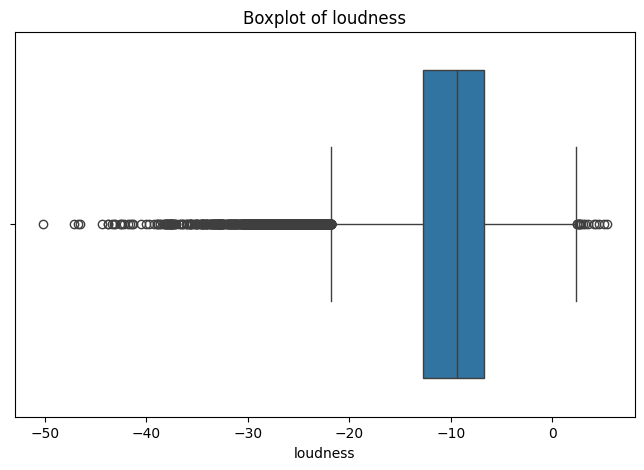

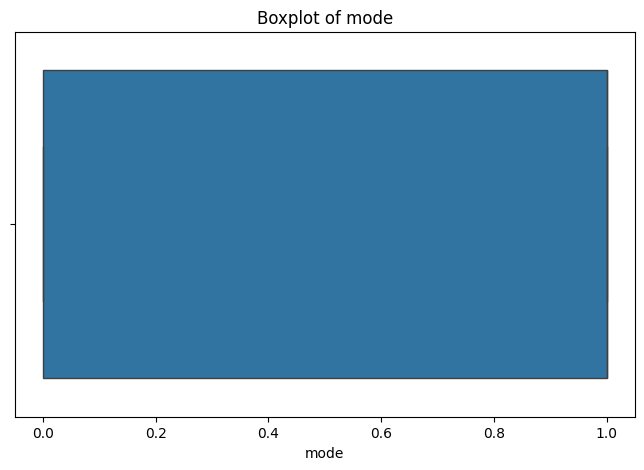

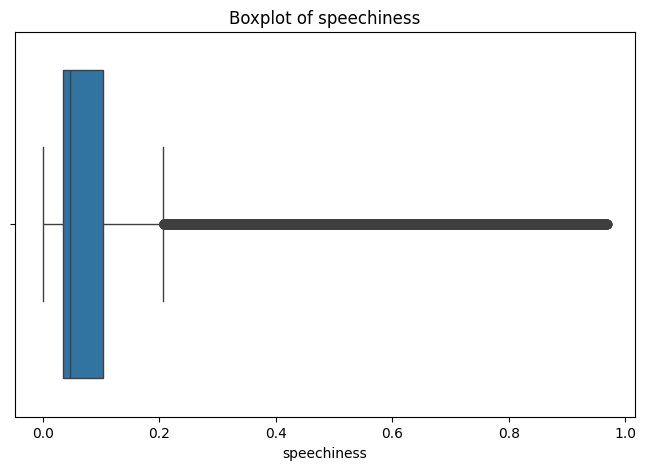

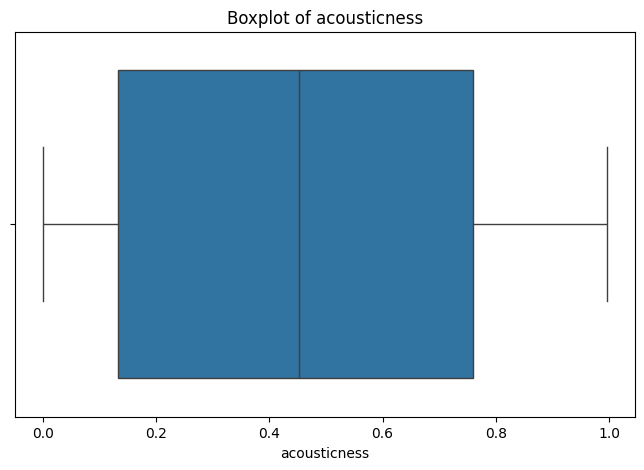

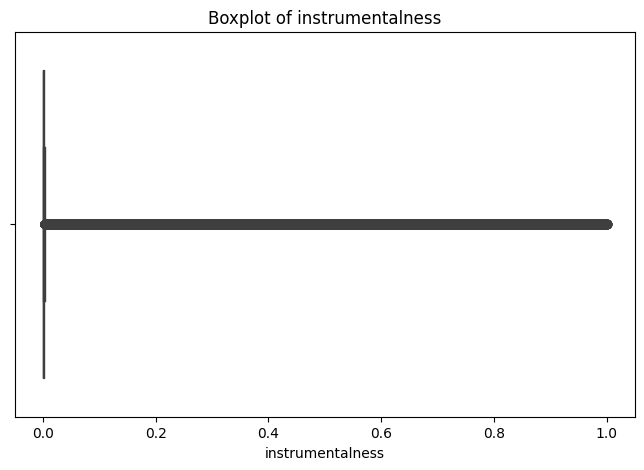

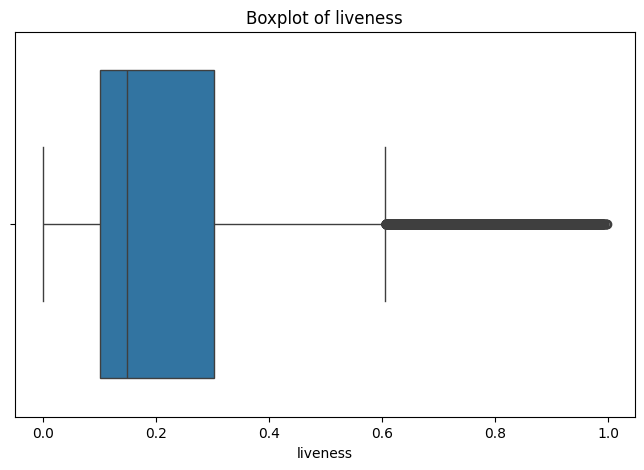

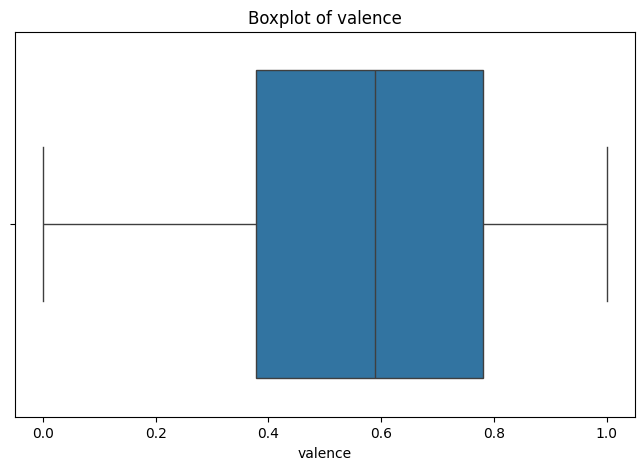

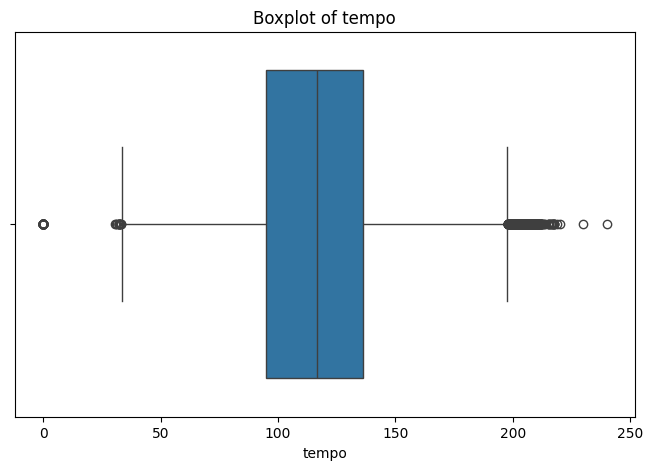

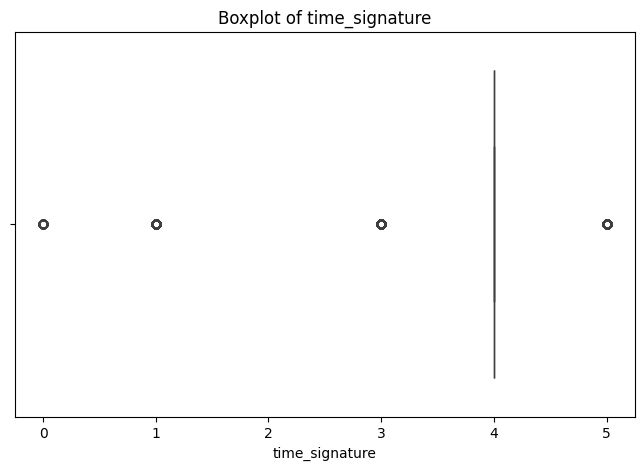

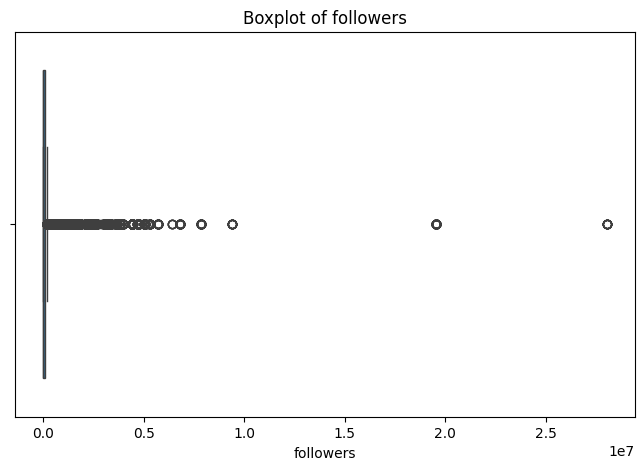

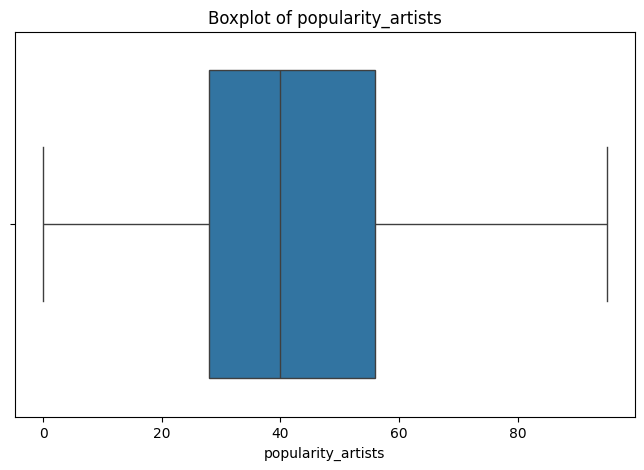

In [17]:
for col in num_cols:

    plt.figure(figsize=(8,5))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

# Correlation Analysis

## Objective

The purpose of correlation analysis is to identify the strength and direction of relationships between numerical features in the dataset.

## Why Correlation Analysis?

- Helps identify highly related features.
- Detects redundant information in the dataset.
- Supports feature selection before clustering.
- Provides insights for feature engineering.
- Helps understand which variables move together.

## Correlation Values Interpretation

| Correlation Value | Interpretation |
|-------------------|---------------|
| +1.0 | Perfect Positive Relationship |
| +0.7 to +0.9 | Strong Positive Relationship |
| +0.3 to +0.7 | Moderate Positive Relationship |
| 0 | No Relationship |
| -0.3 to -0.7 | Moderate Negative Relationship |
| -0.7 to -0.9 | Strong Negative Relationship |
| -1.0 | Perfect Negative Relationship |

## Business Impact

Correlation analysis helps identify important audio characteristics that influence song popularity and artist popularity. It also helps reduce feature redundancy before applying dimensionality reduction and clustering algorithms.

## Expected Outcome

- Identify strongly correlated features.
- Detect multicollinearity.
- Support feature engineering decisions.
- Improve clustering performance through better feature selection.

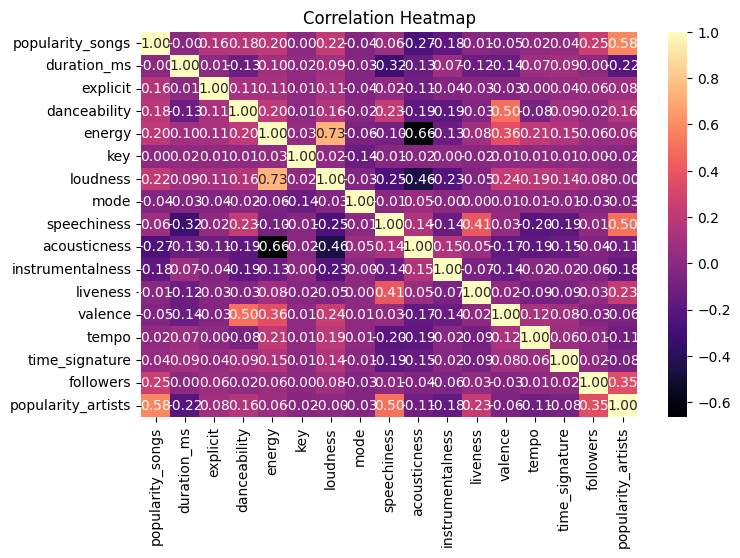

In [18]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='magma',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

# Correlation Analysis - Observations

## Key Findings

### 1. Energy and Loudness
- Correlation ≈ 0.73
- Strong Positive Correlation

Observation:
Songs with higher energy generally have higher loudness levels.

Business Insight:
Energetic songs are usually produced with higher volume intensity.

---

### 2. Energy and Acousticness
- Correlation ≈ -0.66
- Strong Negative Correlation

Observation:
As energy increases, acousticness tends to decrease.

Business Insight:
Highly energetic songs are generally less acoustic and more electronically produced.

---

### 3. Popularity of Songs and Popularity of Artists
- Correlation ≈ 0.58
- Moderate Positive Correlation

Observation:
Popular artists tend to have more popular songs.

Business Insight:
Artist reputation significantly contributes to song popularity.

---

### 4. Danceability and Valence
- Correlation ≈ 0.50
- Moderate Positive Correlation

Observation:
More danceable songs often have a happier or more positive mood.

Business Insight:
Upbeat songs generally encourage listener engagement.

---

### 5. Speechiness and Popularity of Artists
- Correlation ≈ 0.50
- Moderate Positive Correlation

Observation:
Artists with higher popularity often have tracks with noticeable speech-based content.

---

### 6. Speechiness and Liveness
- Correlation ≈ 0.41
- Moderate Positive Correlation

Observation:
Live recordings tend to contain more spoken-word elements.

---

## Multicollinearity Check

Threshold Used:
| Correlation | > 0.80 |

Result:
No feature pair exceeds the threshold.

Conclusion:
No feature needs to be removed at this stage based on correlation alone.

---

## Clustering Perspective

Since K-Means relies on distance calculations:

- Highly correlated features can dominate cluster formation.
- Current dataset does not show severe multicollinearity.
- Features can be retained for further preprocessing.

---

## Next Step

Apply Log Transformation on highly right-skewed features identified during outlier analysis.

Expected Features:

- followers
- duration_ms
- speechiness
- instrumentalness
- liveness
- popularity_songs

After Log Transformation:
- Recheck distributions.
- Perform Feature Scaling.
- Proceed towards PCA and K-Means Clustering.

# Log Transformation

## Why Log Transformation?

During outlier analysis and distribution analysis, several numerical features showed:

- Heavy right skewness
- Long tails
- Extreme values (outliers)

Examples:

- followers
- duration_ms
- speechiness
- instrumentalness
- liveness

These features can dominate distance calculations in clustering algorithms such as K-Means.

---

## What is Log Transformation?

Log Transformation is a mathematical technique used to compress large values while preserving the overall pattern of the data.

Example:

| Original Value | Log1p Value |
|---------------|-------------|
| 10 | 2.39 |
| 100 | 4.61 |
| 1,000 | 6.91 |
| 10,000 | 9.21 |

Observation:

Large values shrink significantly, reducing the impact of extreme observations.

---

## Why Are We Applying It?

### 1. Reduce Skewness

Transforms highly skewed distributions into more balanced distributions.

### 2. Reduce Outlier Influence

Extreme values become less dominant.

### 3. Improve Distance-Based Clustering

K-Means relies on Euclidean Distance.

Without transformation:

- Large-valued features dominate clustering.
- Smaller features contribute less.

After transformation:

- Features contribute more fairly.

### 4. Improve Feature Scaling Effectiveness

Scaling performs better when distributions are less skewed.

---

## Why Use np.log1p() Instead of np.log()?

Formula:

log1p(x) = log(1 + x)

Advantage:

- Handles zero values safely.
- Prevents undefined calculations.

Example:

log(0) → Error

log1p(0) → 0

---

## Features Selected for Log Transformation

The following columns showed strong right-skewness and/or significant outliers:

- followers
- duration_ms
- speechiness
- instrumentalness
- liveness

---

## Expected Outcome

After Log Transformation:

- Distributions become more balanced.
- Outlier influence decreases.
- K-Means clustering becomes more reliable.
- PCA performance improves.
- Feature scaling becomes more effective.

---


In [19]:
import numpy as np

log_cols = [
    'followers',
    'duration_ms',
    'speechiness',
    'instrumentalness',
    'liveness'
]

for col in log_cols:
    df[col] = np.log1p(df[col])

print("Log Transformation Applied Successfully")

Log Transformation Applied Successfully


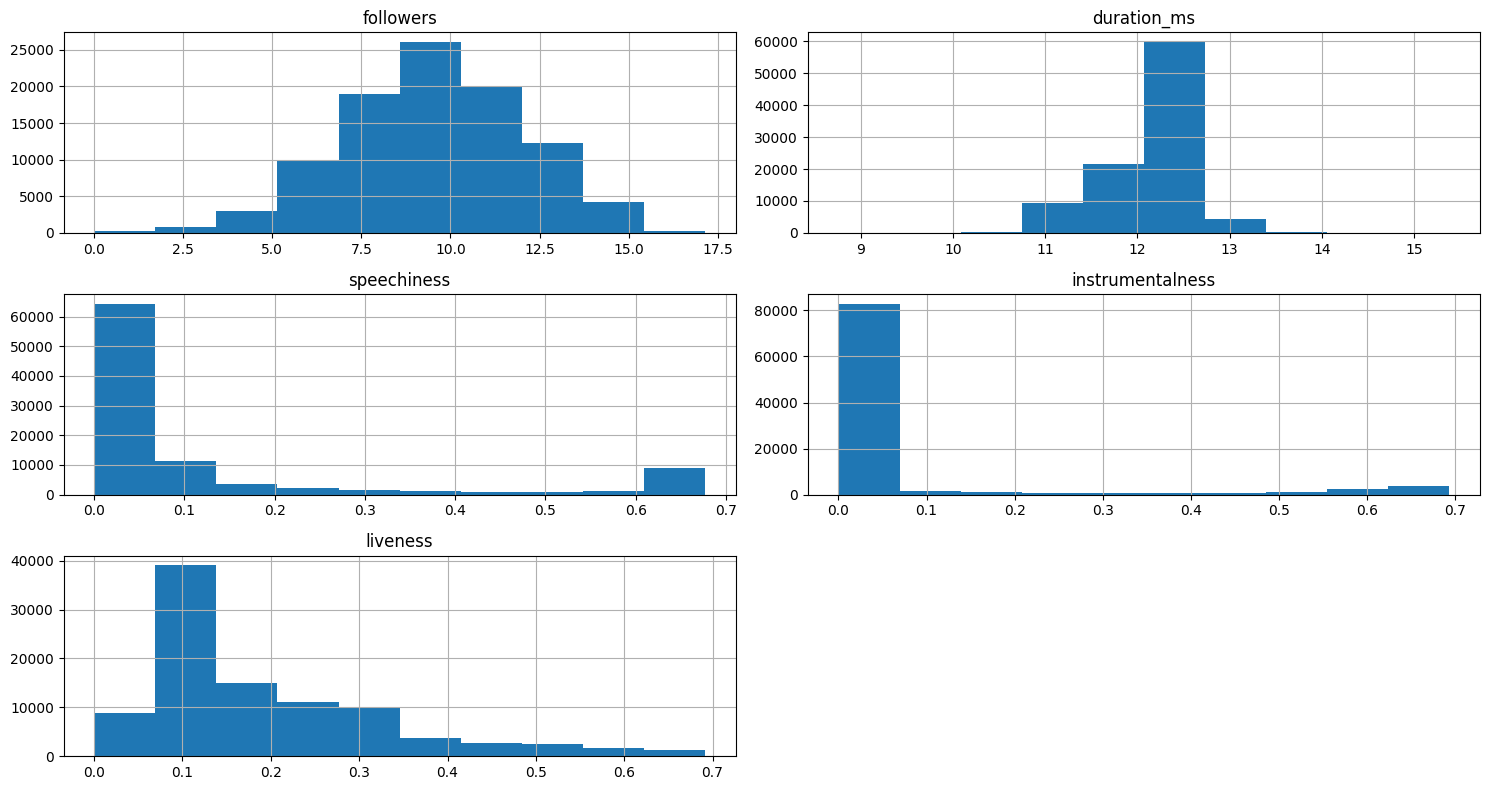

In [20]:
df[log_cols].hist(figsize=(15,8))

plt.tight_layout()

plt.show()

# Feature Engineering - Categorical Feature Analysis

## Objective

Before applying Scaling, PCA, and K-Means Clustering, it is important to analyze the remaining categorical features and determine whether they contain useful information for clustering.

Currently, two important columns remain unexplored:

- release_date
- genres

---

## Why Are We Doing This?

So far, most preprocessing has focused on numerical features.

However, categorical columns may also contain valuable patterns that can improve cluster quality.

If useful information exists in these columns, we should convert it into meaningful numerical features before building the clustering model.

---

## Feature 1: release_date

The release_date column contains information about when a song was released.

Potential insights:

- Older vs newer songs
- Trends across different years
- Song age impact on popularity

Possible feature engineering:

- Release Year
- Release Month
- Song Age

These engineered features may help K-Means identify meaningful groups of songs.

---

## Feature 2: genres

The genres column represents the musical category of a song.

Examples:

- Pop
- Rock
- Hip-Hop
- Dance
- Electronic

Genres often contain strong behavioural patterns and can significantly influence clustering results.

Before deciding how to handle this column, we need to understand:

- Number of unique genres
- Data format
- Missing values
- Complexity of genre combinations

---

## Why Analyze Before Encoding?

Encoding should not be performed blindly.

First, we must understand:

- Data structure
- Cardinality
- Business relevance

This helps us choose the most appropriate encoding strategy and avoid creating unnecessary features.

---

## Expected Outcome

After this analysis, we will decide:

- Which categorical columns should be kept
- Which columns should be transformed
- Which columns should be removed

The final feature set will then be prepared for:

1. Feature Scaling
2. PCA (Dimensionality Reduction)
3. K-Means Clustering
4. Cluster Interpretation

---

In [21]:
df['release_date'].head()

0    1922
1    1922
2    1922
3    1924
4    1924
Name: release_date, dtype: str

In [22]:
df['release_date'].nunique()

10436

In [23]:
df['genres'].head()

0    ['vintage chanson']
1    ['vintage chanson']
2    ['vintage chanson']
3    ['vintage chanson']
4    ['vintage chanson']
Name: genres, dtype: str

In [24]:
df['genres'].nunique()

3153

In [25]:
df['release_date'].sample(20)

64777    2012-02-22
90691    2005-09-15
93019          1996
1904           1942
84360          2007
68098          1994
68051    1988-01-01
45520    1986-01-01
95189    1972-01-01
62687    2000-02-21
44496    1981-01-01
9545     1968-04-13
37692          2005
57395    1995-01-01
56184    1996-01-01
13748    1985-01-01
25614    1997-01-01
15107    1979-01-06
9943           1969
72228    2004-03-02
Name: release_date, dtype: str

In [26]:
df['genres'].sample(20)

83576             ['musica triste brasileira']
38860                              ['cartoon']
81648                 ['singaporean mandopop']
6087                           ['jazz guitar']
92777                            ['kayokyoku']
49798                     ['classic schlager']
94770                       ['polish hip hop']
28382                                ['filmi']
71469                     ['classic thai pop']
37812    ['hip hop', 'indie soul', 'neo soul']
24487                         ['new wave pop']
88422                     ['kleine hoerspiel']
13903                            ['hoerspiel']
26030                          ['mellow gold']
37567                  ['deep tropical house']
95252                         ['swedish punk']
56415                          ['israeli pop']
58632                      ['russian hip hop']
65251                                  ['opm']
62211                           ['czech rock']
Name: genres, dtype: str

In [27]:
df['genres'].value_counts().head(20)

genres
['hoerspiel']                8027
['kleine hoerspiel']         2081
[]                           1876
['classic israeli pop']      1180
['vintage taiwan pop']       1097
['classic thai pop']          939
['j-pop']                     911
['turkish pop']               846
['indonesian pop']            813
['chanson']                   769
['kayokyoku']                 673
['classic icelandic pop']     641
['arabesk']                   609
['classic turkish pop']       602
['classic hungarian pop']     593
['rock uruguayo']             593
['thai pop']                  587
['filmi']                     580
['opm']                       558
['slovak pop']                530
Name: count, dtype: int64

## Feature Engineering: Release Year Extraction

The `release_date` column contains mixed date formats. Some records store complete dates (`YYYY-MM-DD`), while others contain only the release year (`YYYY`).

For clustering, the exact day and month are not important. The release year provides sufficient information about the song's time period and musical era.

Therefore, the release date is converted into a numerical `release_year` feature. This reduces complexity, improves consistency, and creates a machine-learning-friendly feature that can be used during clustering.

### Checking Release Day again:

In [28]:
df['release_date'].sample(20)

45121    1986-04-05
16595    1980-10-03
28622    2006-02-22
33998    2012-01-01
40070    1977-01-01
21828    1982-04-01
74017    2015-03-13
88487    2008-04-25
58424    2003-08-21
4285           1959
17021    1991-03-20
35636    2020-06-03
81468    2008-09-19
95039    2011-08-18
27342    1998-11-10
3734     1945-05-02
93218    2001-11-07
45376    1990-06-14
48299          1960
29469    1999-01-01
Name: release_date, dtype: str

In [29]:
df['release_year']= df['release_date'].str[:4].astype(int)

### Now checking the release year:

In [30]:
df[['release_date','release_year']].sample(10)

,release_date,release_year
61996,1996-01-01,1996
80649,2014-01-01,2014
83615,2019-05-03,2019
57403,1979-01-01,1979
80724,2015-01-01,2015
77669,2019-12-20,2019
30080,1985-01-01,1985
92450,1981,1981
59837,1990-03-16,1990
22692,1984-11-01,1984


### Checking for Missing Values:

In [31]:
df['release_year'].isnull().sum()

np.int64(0)

### Checking for Statistical values of Release year:

In [32]:
df['release_year'].describe()

count    95837.000000
mean      1991.159667
std         20.520136
min       1900.000000
25%       1980.000000
50%       1994.000000
75%       2007.000000
max       2021.000000
Name: release_year, dtype: float64

## Feature Engineering Completion

A new feature called `release_year` has been extracted from the original `release_date` column.

The exact day and month information are not important for clustering analysis. The release year captures the temporal information required for understanding musical eras while reducing feature complexity.

After successful extraction and validation, the original `release_date` column can now be removed from the dataset.

In [33]:
df.drop(columns=['release_date'], inplace=True)

In [34]:
df.columns

Index(['id_songs', 'name_song', 'popularity_songs', 'duration_ms', 'explicit',
       'id_artists', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'followers', 'genres',
       'name_artists', 'popularity_artists', 'release_year'],
      dtype='str')

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  str    
 1   name_song           95837 non-null  str    
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  float64
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  str    
 6   danceability        95837 non-null  float64
 7   energy              95837 non-null  float64
 8   key                 95837 non-null  int64  
 9   loudness            95837 non-null  float64
 10  mode                95837 non-null  int64  
 11  speechiness         95837 non-null  float64
 12  acousticness        95837 non-null  float64
 13  instrumentalness    95837 non-null  float64
 14  liveness            95837 non-null  float64
 15  valence             95837 non-null  float64
 16  tempo          

### Checking for Genres:

In [36]:
df['genres'].value_counts().head(50)


genres
['hoerspiel']                8027
['kleine hoerspiel']         2081
[]                           1876
['classic israeli pop']      1180
['vintage taiwan pop']       1097
['classic thai pop']          939
['j-pop']                     911
['turkish pop']               846
['indonesian pop']            813
['chanson']                   769
['kayokyoku']                 673
['classic icelandic pop']     641
['arabesk']                   609
['classic turkish pop']       602
['classic hungarian pop']     593
['rock uruguayo']             593
['thai pop']                  587
['filmi']                     580
['opm']                       558
['slovak pop']                530
['cumbia uruguaya']           512
['pop romantico']             511
['turkish folk']              503
['classic soundtrack']        501
['israeli pop']               466
['romanian rock']             463
['mandopop']                  463
['musiikkia lapsille']        439
['barnmusik']                 417
['folkl

## Feature Selection for Clustering

We have completed data cleaning, outlier analysis, correlation analysis, log transformation, and feature engineering.

Before applying K-Means Clustering, we must select only meaningful numerical features.

Identifier columns such as song IDs and artist IDs do not contribute to clustering behavior and will be removed.

Text-based columns such as song names and artist names are also excluded because K-Means works only with numerical data.

The genres column will be retained for business interpretation after clustering, but it will not be used during model training because it contains thousands of unique multi-label categories.

In [37]:
drop_cols= [
    'id_songs',
    'name_song',
    'id_artists',
    'name_artists'
]

df_model=df.drop(columns=drop_cols)

In [38]:
df_model.shape

(95837, 19)

## Preparing Features for K-Means Clustering

K-Means clustering works only with numerical features.

The genres column is retained in the dataset for business interpretation and cluster analysis, but it will not be used during model training because it contains high-cardinality multi-label categorical values.

Therefore, we will create a separate clustering dataset containing only numerical features.

In [39]:
X=df_model.drop(columns=['genres'])
X.shape

(95837, 18)

## Feature Scaling

K-Means Clustering is a distance-based machine learning algorithm.

Features such as followers, duration_ms, and popularity_songs have much larger numerical values than features like danceability, energy, and valence.

If scaling is not applied, large-value features will dominate the distance calculations and bias the clustering results.

To ensure that every feature contributes equally, StandardScaler is applied before K-Means training.

After scaling:

- Mean ≈ 0
- Standard Deviation ≈ 1

This improves cluster quality and model performance.

In [40]:
from sklearn.preprocessing import StandardScaler

In [41]:
scaler=StandardScaler()

In [42]:
X_scaled = scaler.fit_transform(X)

In [43]:
X_scaled[:5]

array([[-1.60368627, -0.31134471, -0.17478473, -0.15347598, -1.51112816,
        -0.33856137, -0.75790895,  0.73691607, -0.43441294,  1.61618723,
        -0.36497645,  0.64601176,  0.32128698,  0.51500516, -1.56384556,
        -0.410723  , -0.99624862, -3.37034934],
       [-1.60368627,  0.36871755, -0.17478473, -1.02851842, -1.52805562,
         1.35879716, -1.09862851,  0.73691607, -0.35775349,  1.60408122,
        -0.36506765, -0.52801048, -0.57745518, -1.2944868 , -1.56384556,
        -0.410723  , -0.99624862, -3.37034934],
       [-1.60368627,  0.22160939, -0.17478473, -0.48805103, -1.41802711,
        -1.47013372, -1.12789922,  0.73691607, -0.39545511,  1.62224024,
        -0.36506765,  1.1407722 , -0.37594348, -1.56000306,  0.27302897,
        -0.410723  , -0.99624862, -3.37034934],
       [-1.60368627, -0.30479775, -0.17478473,  0.57358134, -0.31351008,
         1.07590407, -0.4706769 , -1.35700664,  0.09376835,  1.61013423,
        -0.36506765,  0.03786049,  0.61146382,  0.405

## Finding the Optimal Number of Clusters

K-Means requires us to specify the number of clusters (K) before training.

To determine the most suitable value of K, we use the Elbow Method.

The Elbow Method calculates the Within Cluster Sum of Squares (WCSS) for different values of K.

The point where the decrease in WCSS starts slowing down significantly is considered the optimal number of clusters.

In [44]:
from sklearn.cluster import KMeans

In [49]:
wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

In [50]:
wcss

[1725066.00000001,
 1498604.1541642062,
 1309067.301213096,
 1210829.4828075091,
 1136940.8640088094,
 1081905.2971517742,
 1039691.9058847367,
 1010027.7328630268,
 983482.0773064552,
 956194.4472306834]

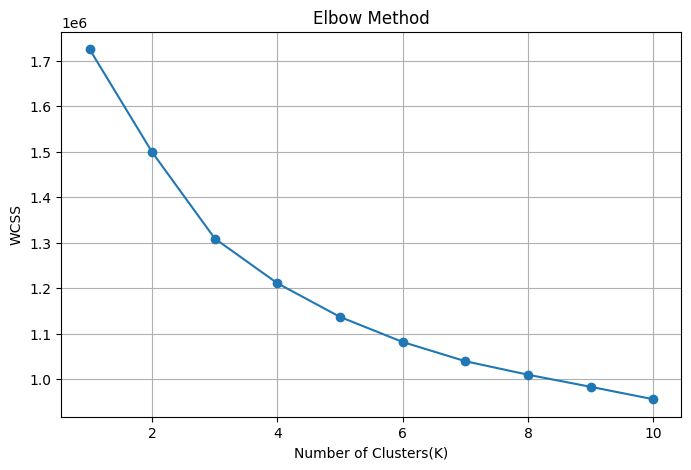

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters(K)")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

# ML Finding Optimal Number of Clusters (Elbow Method)

## Objective
Before applying K-Means Clustering, it is important to determine the optimal number of clusters (K).

## Why Are We Doing This?
K-Means requires us to specify the number of clusters beforehand. Choosing too few clusters may combine different customer/song groups together, while choosing too many clusters may create unnecessary fragmentation.

## Method Used
The Elbow Method was applied by training K-Means models for K values ranging from 1 to 10 and calculating the WCSS (Within Cluster Sum of Squares) for each value.

## Observation
The WCSS decreases rapidly until K = 4 and then starts flattening. This indicates that adding more clusters after K = 4 provides only marginal improvement.

## Conclusion
The elbow point appears around K = 4.

Therefore, K = 4 is selected as the optimal number of clusters for further K-Means clustering analysis.

### K_mean fit::

In [52]:
from sklearn.cluster import KMeans

kmeans= KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters= kmeans.fit_predict(X_scaled)

In [53]:
clusters[:10]

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3], dtype=int32)

In [54]:
df_model['Clusters']= clusters

In [55]:
df_model['Clusters'].value_counts()

Clusters
1    51367
3    29828
2    11802
0     2840
Name: count, dtype: int64

# ML Applying K-Means Clustering

## Objective

After identifying the optimal number of clusters using the Elbow Method, K-Means Clustering was applied with K = 4.

## Why Are We Doing This?

The objective is to group songs with similar characteristics into meaningful clusters based on audio features and artist-related attributes.

## Process

- Applied K-Means Clustering with K = 4
- Generated cluster labels for each song
- Added the cluster assignments back to the dataset

## Cluster Distribution

| Cluster | Number of Songs |
|----------|----------------|
| 0 | 2,840 |
| 1 | 51,367 |
| 2 | 11,802 |
| 3 | 29,828 |

## Observation

Cluster 1 contains the largest number of songs, while Cluster 0 is relatively small. This indicates that the dataset naturally forms groups of different sizes.

## Conclusion

The clustering process successfully assigned all songs into four distinct groups. The next step is to perform cluster profiling to understand the characteristics of each cluster.

# ML Cluster Profiling & Interpretation

## What Are We Doing?

After successfully applying K-Means Clustering, the next step is to understand the characteristics of each cluster.

The clustering algorithm has already grouped similar songs together, but the cluster labels (0, 1, 2, 3) do not provide any business meaning by themselves.

Therefore, cluster profiling is performed to identify the average characteristics of songs present in each cluster.

---

## Why Are We Doing This?

The primary objective of clustering is not only to create groups but also to understand what makes each group unique.

Without profiling, Cluster 0, Cluster 1, Cluster 2, and Cluster 3 are just numbers.

By analyzing the average feature values of each cluster, we can determine:

- Which cluster contains highly energetic songs
- Which cluster contains acoustic songs
- Which cluster contains older songs
- Which cluster contains highly popular songs
- Which cluster contains niche or less popular songs

This helps transform technical clusters into meaningful business insights.

---

## How Does It Work?

The dataset is grouped based on the cluster labels generated by K-Means.

For each cluster, the mean value of numerical features is calculated.

These average values help us compare clusters and identify the dominant characteristics of each group.

---

## Expected Outcome

The output will provide a cluster profile table where each row represents a cluster and each column represents the average value of a feature.

Based on these values, each cluster can be interpreted and assigned a meaningful description.

This is one of the most important steps in the clustering workflow because it converts machine-generated groups into actionable insights.

In [ ]:
cluster_profile = (
    df_model
    .groupby('Clusters')
    .mean(numeric_only=True)
)

cluster_profile.round(2)

,popularity_songs,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,popularity_artists,release_year
Clusters,,,,,,,,,,,,,,,,,,
0,40.89,12.20,1.0,0.69,0.68,5.48,-7.12,0.54,0.18,0.24,0.02,0.17,0.54,118.03,3.97,10.93,52.06,2012.95
1,31.18,12.32,0.0,0.61,0.67,5.30,-7.76,0.63,0.06,0.28,0.04,0.17,0.63,124.38,3.96,10.12,42.84,2000.54
2,30.27,11.29,0.0,0.66,0.48,4.99,-12.96,0.65,0.59,0.56,0.00,0.35,0.58,100.72,3.56,11.42,75.69,1986.05
3,14.18,12.16,0.0,0.50,0.33,5.08,-13.47,0.69,0.08,0.75,0.14,0.17,0.49,112.36,3.77,7.84,28.90,1974.96


# ML Cluster Visualization

## Objective

After understanding the average characteristics of each cluster, visualizations are created to compare clusters more effectively.

## Why Are We Doing This?

Tables provide numerical summaries, but visualizations make it easier to identify differences between clusters.

Charts help us understand:

- Which cluster contains the most popular songs
- Which cluster contains older songs
- Which cluster contains energetic songs
- Which cluster contains acoustic songs

## Method

Cluster-wise average feature values are visualized using bar charts.

## Expected Outcome

The visualizations will provide a clearer understanding of the characteristics of each cluster and help in assigning meaningful business labels.

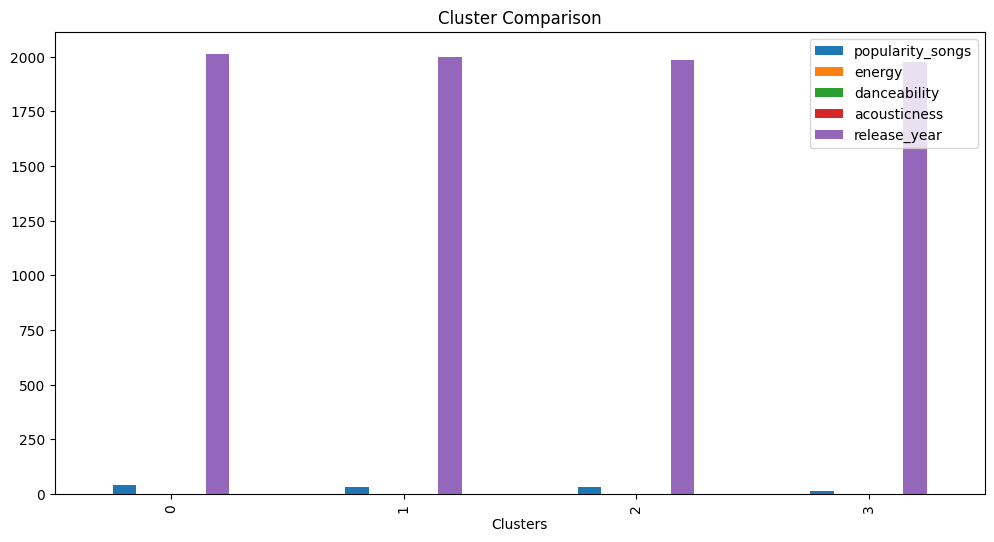

In [ ]:
cluster_profile[['popularity_songs',
                 'energy',
                 'danceability',
                 'acousticness',
                 'release_year']].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Cluster Comparison')
plt.show()

In [ ]:
cluster_profile.T

Clusters,0,1,2,3
popularity_songs,40.887324,31.182160,30.274869,14.180200
duration_ms,12.197983,12.320195,11.293137,12.161316
explicit,1.000000,0.000000,0.000000,0.000034
danceability,0.687120,0.613520,0.660683,0.502172
energy,0.683300,0.670684,0.484169,0.326875
key,5.476761,5.297915,4.993306,5.076472
loudness,-7.119891,-7.760440,-12.961464,-13.466434
mode,0.538028,0.628477,0.650314,0.691397
speechiness,0.175609,0.060653,0.590923,0.077079
acousticness,0.243114,0.276954,0.555448,0.754860


# ML Cluster Interpretation

## What Are We Doing?

After creating clusters using K-Means, we analyze the average feature values of each cluster.

The objective is to understand the characteristics of songs present inside each cluster.

## Why Are We Doing This?

K-Means only assigns numerical labels (0, 1, 2, 3).

These labels do not provide any business meaning.

By studying the average values of features inside each cluster, we can identify what type of songs belong to each group.

## How Does It Work?

We calculate the mean value of all numerical features for every cluster.

The resulting table helps compare clusters feature-by-feature.

## Expected Outcome

Each cluster can be assigned a meaningful business label such as:

- Modern Popular Songs
- Mainstream Songs
- Classic Artist Songs
- Vintage Retro Songs

This makes the clustering results easier to interpret and communicate.

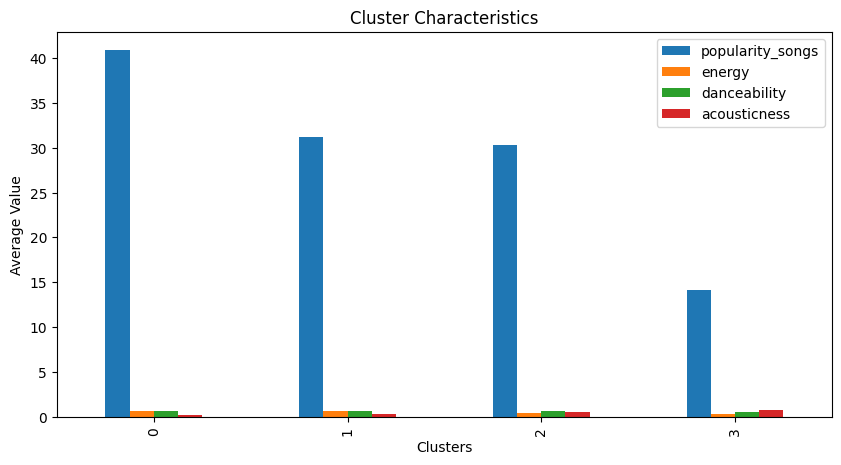

In [ ]:
cluster_profile[['popularity_songs',
                 'energy',
                 'danceability',
                 'acousticness']].plot(
                 kind='bar',
                 figsize=(10,5))

plt.title("Cluster Characteristics")
plt.ylabel("Average Value")
plt.show()

# Business Insights from Clustering

## Objective

The objective of clustering was to identify different groups of songs based on their musical and popularity characteristics.

Using K-Means Clustering, four distinct song segments were discovered.

## Key Findings

### Cluster 0 - Modern Popular Songs

- Highest song popularity
- High energy
- High danceability
- Recent release years

### Cluster 1 - Mainstream Songs

- Moderately popular
- Balanced musical characteristics
- Released mostly around 2000s

### Cluster 2 - Classic Artist Songs

- Highest artist popularity
- Older release years
- More acoustic music

### Cluster 3 - Vintage Retro Songs

- Lowest popularity
- Oldest songs
- Highest acousticness
- Less energetic music

## Business Value

The clustering model successfully segmented songs into meaningful categories that can support recommendation systems, playlist generation, audience targeting, and music discovery.

# Final Conclusion

This project successfully applied K-Means Clustering to segment songs based on musical attributes and popularity metrics.

The dataset was cleaned, transformed, and standardized before clustering.

The Elbow Method identified four optimal clusters.

Cluster profiling revealed meaningful groups ranging from modern popular songs to vintage acoustic tracks.

The results demonstrate how unsupervised machine learning can uncover hidden patterns in music data and support business decision-making for recommendation systems and user personalization.

# Cluster Evaluation - Silhouette Score

## Objective

After creating clusters using K-Means, it is important to evaluate the quality of clustering.

Silhouette Score measures how well each data point fits within its assigned cluster compared to other clusters.

## Why Are We Using It?

The Elbow Method helps estimate the optimal number of clusters, but it does not measure cluster quality.

Silhouette Score provides a quantitative measure of cluster separation and cohesion.

## Interpretation

- Close to +1 → Well-separated clusters
- Around 0 → Overlapping clusters
- Negative → Poor clustering

## Expected Outcome

A higher Silhouette Score indicates better cluster formation and stronger separation between groups.

In [ ]:
from sklearn.metrics import silhouette_score

In [ ]:
#sil_score= silhouette_score(X_scaled, clusters)

#print("Silhouette Score :", round(sil_score, 4))

### Got an error:: Memory error.

### Observation

Direct Silhouette Score calculation on the full dataset resulted in a Memory Error because the dataset contains nearly 96,000 records.

To overcome this limitation, a sampled dataset will be used for cluster evaluation.

This approach is commonly used in industry projects when working with large datasets and provides a reliable estimate of clustering quality while reducing computational cost.

In [ ]:
X_smaple = X_scaled[:10000]

clusters_sample = clusters[:10000]

In [ ]:
X_smaple.shape

(10000, 18)

### Now calculating Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score

In [ ]:
sil_score = silhouette_score(
    X_smaple,
    clusters_sample
)

print("Silhouette Score :", round(sil_score,4))



Silhouette Score : 0.0893


## 📊 Cluster Evaluation – Silhouette Score

### Objective

To evaluate the quality of clusters generated by the K-Means algorithm.

### Result

Silhouette Score = **0.0893**

### Interpretation

The score is positive, indicating that the clusters are meaningful and better than random grouping.

However, the score is relatively low, suggesting that the boundaries between clusters are not sharply separated.

### Why?

Music-related features such as danceability, energy, acousticness, and popularity often overlap across songs. As a result, songs from different clusters may still share similar characteristics.

### Conclusion

The K-Means model successfully identified different song groups, but the cluster separation is moderate rather than strong.

Despite the low score, cluster profiling revealed meaningful business insights and interpretable song segments.

## 📊 Cluster Evaluation – Davies-Bouldin Index

### Objective

After evaluating cluster quality using Silhouette Score, we will use the Davies-Bouldin Index (DBI) as an additional clustering evaluation metric.

### Why?

Different evaluation metrics measure clustering quality from different perspectives.

While Silhouette Score focuses on cluster separation, Davies-Bouldin Index measures:

- Cluster compactness
- Cluster similarity
- Cluster overlap

### Interpretation

Lower DBI values indicate better clustering performance.

| DBI Value | Interpretation |
|------------|---------------|
| Close to 0 | Excellent clustering |
| < 1 | Good clustering |
| > 1 | Weak clustering |

### Expected Outcome

A lower Davies-Bouldin score indicates that clusters are compact and well separated from each other.

In [ ]:
from sklearn.metrics import davies_bouldin_score

In [ ]:
db_score = davies_bouldin_score(
    X_smaple,
    clusters_sample
)

print("Davies-Bouldin Score :", round(db_score, 4) )

Davies-Bouldin Score : 1.7732


## 📊 Cluster Evaluation – Davies-Bouldin Index (DBI)

### Objective

To evaluate cluster quality using an additional clustering metric called the Davies-Bouldin Index.

### Result

Davies-Bouldin Score = **1.7732**

### Interpretation

The Davies-Bouldin Index measures the similarity between clusters.

Lower values indicate better clustering performance.

| DBI Value | Interpretation |
|-----------|---------------|
| Close to 0 | Excellent Clustering |
| < 1 | Good Clustering |
| > 1 | Weak Cluster Separation |

### Analysis

The obtained DBI score suggests that some clusters overlap with each other and are not perfectly separated.

This behavior is expected in music datasets because many songs share similar characteristics such as energy, danceability, popularity, and acousticness.

### Conclusion

Although the cluster separation is moderate, the K-Means model successfully identified meaningful song segments that can be interpreted from a business perspective.

Cluster profiling revealed distinct groups based on popularity, release period, artist popularity, and musical characteristics.

## 📊 PCA (Principal Component Analysis)

### Objective

The dataset currently contains 18 numerical features.

Visualizing 18-dimensional data is impossible for humans.

Therefore, PCA (Principal Component Analysis) will be used to reduce the dimensionality of the dataset while preserving most of the important information.

### Why PCA?

- Reduces dimensionality
- Removes redundancy
- Makes visualization easier
- Helps understand cluster separation

### How PCA Works?

PCA creates new features called Principal Components.

These components capture the maximum variance present in the original dataset.

Example:

18 Features
↓
PCA
↓
2 Principal Components (PC1, PC2)

### Expected Outcome

A 2D representation of the dataset that allows visualization of cluster distribution and overlap.

In [ ]:
from sklearn.decomposition import PCA

### Creating an object:

In [ ]:
pca=PCA(n_components=2)

In [ ]:
X_pca=pca.fit_transform(X_scaled)

In [ ]:
X_pca.shape


(95837, 2)

## 📊 PCA Explained Variance Analysis

### Objective

After reducing the dataset from 18 features to 2 principal components, we need to measure how much information has been retained.

### Why?

Dimensionality reduction always causes some information loss.

Explained Variance tells us how much of the original dataset's variability is captured by the selected principal components.

### Interpretation

Higher explained variance indicates that the reduced dimensions still represent the original dataset effectively.

### Expected Outcome

A percentage value showing how much information is preserved after PCA transformation.

In [ ]:
pca.explained_variance_ratio_

array([0.19531129, 0.15533543])

In [ ]:
pca.explained_variance_ratio_.sum()

np.float64(0.3506467155748536)

### Observation

The first principal component (PC1) captures approximately **19.53%** of the total variance, while the second principal component (PC2) captures approximately **15.53%**.

Together, the first two principal components explain **35.06%** of the total variance present in the original dataset.

This indicates that the 18-dimensional dataset has been compressed into a 2-dimensional representation while retaining a meaningful portion of the original information.

Although some information is lost during dimensionality reduction, the resulting 2D representation is sufficient for cluster visualization and interpretation.

In [ ]:
pca_df= pd.DataFrame(
    X_pca,
    columns= ['PC1','PC2']
)

pca_df.head()

,PC1,PC2
0,-3.785625,0.415159
1,-4.344118,0.267691
2,-4.048402,0.594916
3,-2.700427,-0.121584
4,-3.306882,0.592118


In [ ]:
pca_df['Clusters'] = clusters

In [ ]:
pca_df.head()

,PC1,PC2,Clusters
0,-3.785625,0.415159,3
1,-4.344118,0.267691,3
2,-4.048402,0.594916,3
3,-2.700427,-0.121584,3
4,-3.306882,0.592118,3


## 📊 PCA Cluster Visualization

### Objective

After reducing the dataset to two principal components, we visualize the clusters in a 2D space.

### Why?

Cluster evaluation metrics provide numerical insights, but visualization helps us understand cluster overlap and separation visually.

### Expected Outcome

A scatter plot showing the distribution of songs across different clusters using the first two principal components.

In [ ]:
import matplotlib.pyplot as plt

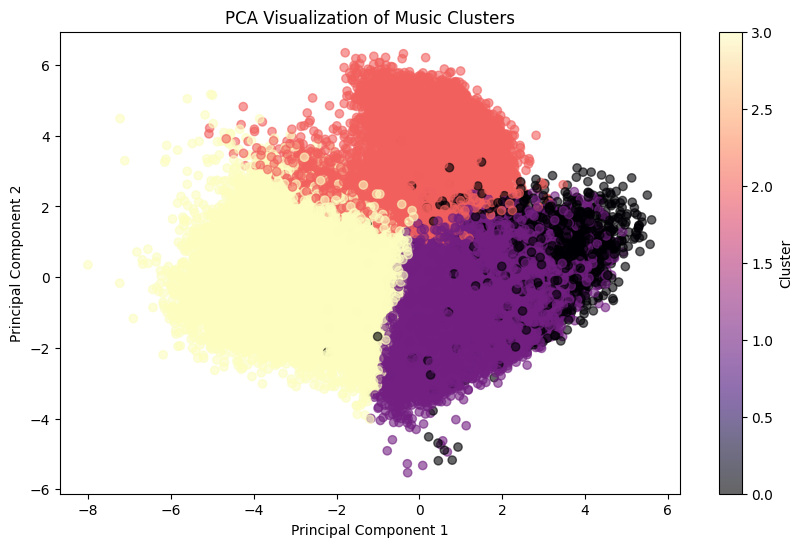

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['Clusters'],
    cmap='magma',
    alpha=0.6
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.title('PCA Visualization of Music Clusters')

plt.colorbar(label='Cluster')

plt.show()

## 📊 PCA Cluster Visualization Analysis

### Objective

To visualize the K-Means clusters in a two-dimensional space using PCA.

### Observation

The PCA scatter plot shows that the dataset has been divided into four major clusters.

Two clusters appear relatively well separated, while some overlap exists between the remaining clusters.

### Interpretation

- Cluster separation is visible in the PCA space.
- Some clusters are compact and distinct.
- Certain clusters overlap, indicating similarities in musical characteristics.

### Relation with Evaluation Metrics

The overlap observed in the PCA plot explains:

- Low Silhouette Score (0.0893)
- Moderate Davies-Bouldin Score (1.7732)

These metrics suggest that while meaningful clusters exist, the boundaries between some groups are not sharply defined.

### Conclusion

The PCA visualization confirms that K-Means successfully identified multiple song segments, although partial overlap exists due to the natural similarity between music features.

In [ ]:
cluster_names = {
    0: "Popular Modern Hits",
    1: "Mainstream Songs",
    2: "Artist-Driven Classics",
    3: "Vintage Acoustic Tracks"
}

df_model['Cluster_Name'] = df_model['Clusters'].map(cluster_names)

df_model[["Clusters","Cluster_Name"]].head()

,Clusters,Cluster_Name
0,3,Vintage Acoustic Tracks
1,3,Vintage Acoustic Tracks
2,3,Vintage Acoustic Tracks
3,3,Vintage Acoustic Tracks
4,3,Vintage Acoustic Tracks


In [ ]:
df_model["Cluster_Name"].value_counts()

Cluster_Name
Mainstream Songs           51367
Vintage Acoustic Tracks    29828
Artist-Driven Classics     11802
Popular Modern Hits         2840
Name: count, dtype: int64

## 🎵 Cluster Naming & Business Interpretation

To make the clustering results easier to understand, numeric cluster labels were mapped to meaningful business-oriented names.

### Cluster Distribution

| Cluster Name | Count |
|-------------|--------:|
| Mainstream Songs | 51,367 |
| Vintage Acoustic Tracks | 29,828 |
| Artist-Driven Classics | 11,802 |
| Popular Modern Hits | 2,840 |

### Key Insights

- Mainstream Songs represent the largest segment of the music catalog.
- Vintage Acoustic Tracks contain older and highly acoustic music.
- Artist-Driven Classics consist of tracks associated with highly popular artists.
- Popular Modern Hits represent recent and highly popular songs.

This step converts technical clustering results into business-friendly insights that can support recommendation systems and audience segmentation.

### Checking for one final time befor saving and writing Business Insights::

In [ ]:
df_model.head()

,popularity_songs,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,popularity_artists,release_year,Clusters,Cluster_Name
0,0,11.991815,0,0.563,0.184,4,-13.757,1,0.049932,0.993,0.000015,0.281412,0.654,133.088,3,8.53287,['vintage chanson'],22,1922,3,Vintage Acoustic Tracks
1,0,12.316903,0,0.427,0.180,10,-15.375,1,0.064851,0.989,0.000000,0.120446,0.431,78.459,3,8.53287,['vintage chanson'],22,1922,3,Vintage Acoustic Tracks
2,0,12.246581,0,0.511,0.206,0,-15.514,1,0.057514,0.995,0.000000,0.349247,0.481,70.443,4,8.53287,['vintage chanson'],22,1922,3,Vintage Acoustic Tracks
3,0,11.994944,0,0.676,0.467,9,-12.393,0,0.152721,0.991,0.000000,0.198031,0.726,129.775,4,8.53287,['vintage chanson'],22,1924,3,Vintage Acoustic Tracks
4,0,12.031564,0,0.650,0.298,9,-13.806,1,0.129272,0.991,0.000000,0.316998,0.844,75.950,4,8.53287,['vintage chanson'],22,1924,3,Vintage Acoustic Tracks


## 📊 Cluster-wise Business Insight Analysis

After successfully creating clusters using the K-Means algorithm, the next step is to analyze and compare the characteristics of each cluster.

In this section, average values of key features such as song popularity, energy, danceability, acousticness, artist popularity, and release year are calculated for every cluster. This helps in understanding the unique behavior of each group and identifying the factors that differentiate one cluster from another.

The objective of this analysis is to transform machine learning clusters into meaningful business segments that can support recommendation systems, audience targeting, playlist creation, and content strategy decisions.

In [ ]:
df_model.groupby("Cluster_Name").agg({
    "popularity_songs":"mean",
    "energy":"mean",
    "danceability":"mean",
    "acousticness":"mean",
    "popularity_artists":"mean",
    "release_year":"mean"
}).round(2)


,popularity_songs,energy,danceability,acousticness,popularity_artists,release_year
Cluster_Name,,,,,,
Artist-Driven Classics,30.27,0.48,0.66,0.56,75.69,1986.05
Mainstream Songs,31.18,0.67,0.61,0.28,42.84,2000.54
Popular Modern Hits,40.89,0.68,0.69,0.24,52.06,2012.95
Vintage Acoustic Tracks,14.18,0.33,0.50,0.75,28.90,1974.96


## 📈 Cluster Interpretation & Business Insights

After analyzing the average feature values of each cluster, meaningful business insights can be extracted from the segmented music groups.

The objective of this step is to understand the characteristics of each cluster and identify how different groups of songs vary in terms of popularity, energy, danceability, acousticness, artist popularity, and release period.

These insights help transform machine learning outputs into business-friendly interpretations that can support recommendation systems, playlist generation, audience segmentation, and content strategy decisions.

## 🎯 Cluster-wise Business Insights

Based on the average feature values, four distinct music segments were identified.

### Popular Modern Hits
- Highest song popularity among all clusters.
- High energy and danceability scores.
- Contains relatively recent songs.
- Represents trending and commercially successful music preferred by modern listeners.

### Mainstream Songs
- Balanced popularity and energy levels.
- Moderate acousticness and danceability.
- Represents songs that appeal to a broad audience segment.
- Forms the largest music segment in the dataset.

### Artist-Driven Classics
- Highest artist popularity score.
- Contains older songs from well-known artists.
- Popularity is influenced more by artist reputation than current music trends.
- Represents classic tracks with strong artist recognition.

### Vintage Acoustic Tracks
- Highest acousticness value.
- Lowest popularity and energy levels.
- Contains the oldest songs in the dataset.
- Represents traditional, acoustic, and niche music preferred by specific listener groups.

### Overall Observation
The clustering process successfully segmented the music catalog into four meaningful groups based on popularity, artist influence, musical characteristics, and release period. These segments can be useful for recommendation systems, playlist generation, audience targeting, and content strategy decisions.

### Checking for common Genres::

In [ ]:
df_model.groupby("Cluster_Name")["genres"]\
        .agg(lambda x: x.mode().iloc[0])

Cluster_Name
Artist-Driven Classics              ['hoerspiel']
Mainstream Songs                        ['j-pop']
Popular Modern Hits              ['czsk hip hop']
Vintage Acoustic Tracks    ['vintage taiwan pop']
Name: genres, dtype: str

## 🎵 Dominant Genre Analysis

To better understand the musical identity of each cluster, the most frequently occurring genre was identified for every music segment.

### Dominant Genres by Cluster

| Cluster Name | Dominant Genre |
|-------------|----------------|
| Artist-Driven Classics | hoerspiel |
| Mainstream Songs | j-pop |
| Popular Modern Hits | czsk hip hop |
| Vintage Acoustic Tracks | vintage taiwan pop |

### Key Observations

- Artist-Driven Classics are primarily associated with hoerspiel content and highly recognized artists.
- Mainstream Songs are strongly represented by j-pop music and appeal to a broad listener base.
- Popular Modern Hits show a stronger presence of contemporary genres such as czsk hip hop.
- Vintage Acoustic Tracks are dominated by vintage taiwan pop and represent older acoustic-focused music.

This analysis provides additional context to the clusters and helps understand the genre distribution within each music segment.

### 📊 Cluster Feature Heatmap

This heatmap visualizes the average values of important audio features across all music clusters.

It helps compare cluster characteristics more effectively by highlighting strong and weak feature values. This visualization provides a quick overview of how each cluster differs from the others and supports business interpretation of the clustering results.

To improve the visualization of cluster characteristics, a normalized heatmap is created using Min-Max Scaling.

The original cluster profile contains features with different value ranges. For example, `energy` ranges between 0 and 1, while `release_year` is around 1900–2021. If these features are plotted directly, large-scale features dominate the color intensity, making it difficult to compare the remaining features.

Therefore, Min-Max Scaling is applied only for visualization purposes. The scaled values allow all features to contribute equally to the heatmap, making cluster comparisons clearer and more meaningful. The original values remain unchanged and are already presented in the cluster profiling table.

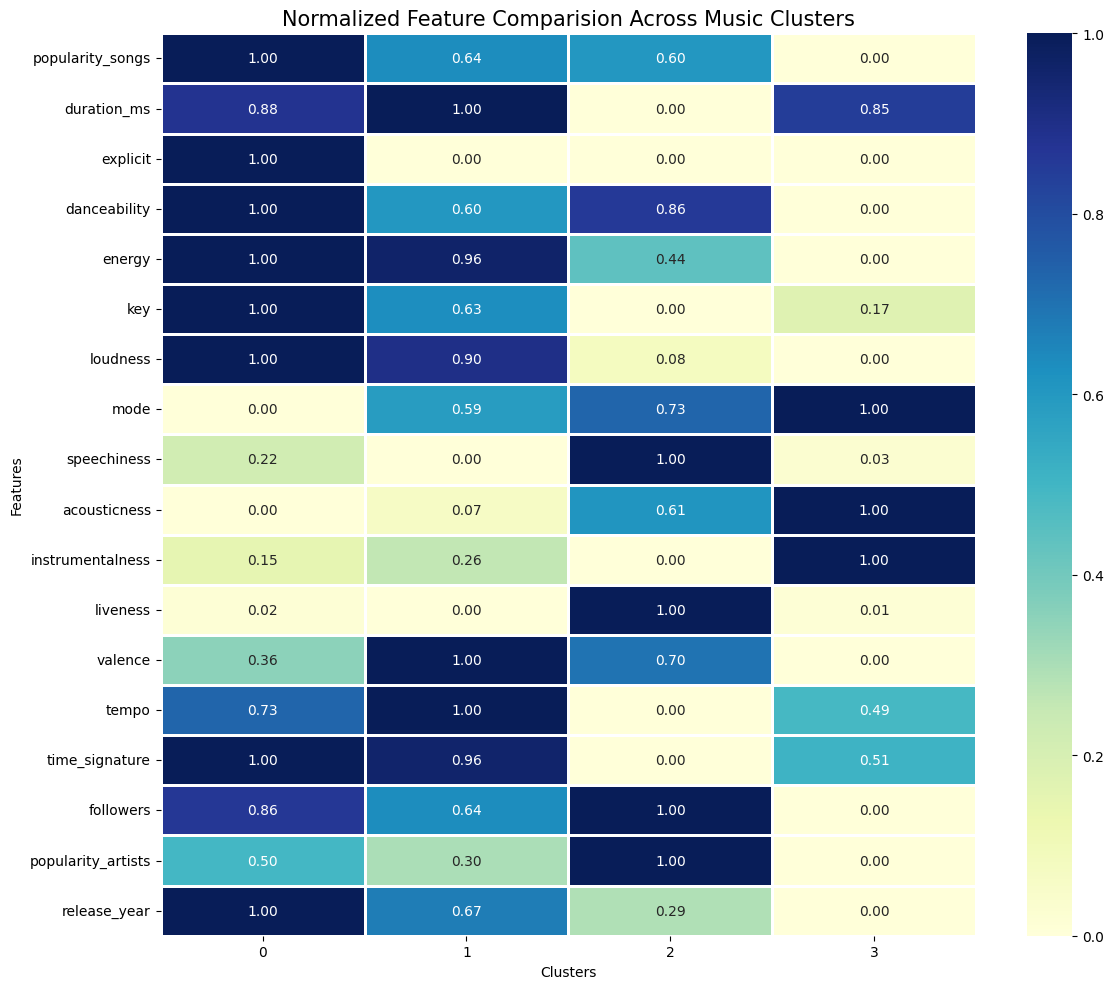

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Normalize cluster profile only for visulaization

scaler=MinMaxScaler()

scaled_heatmap = pd.DataFrame(
    scaler.fit_transform(cluster_profile),
    columns= cluster_profile.columns,
    index= cluster_profile.index
)

#Plot HeatMap:

plt.figure(figsize=(12,10))

sns.heatmap(
    scaled_heatmap.T,
    cmap="YlGnBu",
    
    linewidths=0.8,
    annot=True,
    fmt='.2f'
)

plt.title("Normalized Feature Comparision Across Music Clusters", fontsize=15)
plt.xlabel("Clusters")
plt.ylabel("Features")

plt.tight_layout()
plt.show()



### Observation

The normalized heatmap provides a clear comparison of feature importance across all music clusters.

Min-Max Scaling was applied only for visualization so that features with different value ranges contribute equally to the color intensity. This prevents large-scale features such as `release_year` from dominating the visualization.

Each row represents a music feature, while each column represents a cluster. Darker colors indicate relatively higher normalized values, whereas lighter colors indicate lower values within that feature.

This visualization makes it easier to identify the distinguishing characteristics of each cluster and supports business interpretation of the clustering results. The original feature values remain available in the cluster profiling table and are not modified.

### Analysis of the Heatmap:

The normalized heatmap highlights the relative distribution of feature values across all four music clusters.

- Cluster 0 shows the highest popularity, energy, danceability, loudness, and recent release years, representing modern hit songs.
- Cluster 1 contains balanced feature values across most variables, indicating mainstream songs with broad audience appeal.
- Cluster 2 exhibits higher speechiness, liveness, artist popularity, and follower count, suggesting artist-driven or performance-oriented music.
- Cluster 3 is characterized by high acousticness and instrumentalness while showing lower popularity, lower energy, and older release years, representing vintage acoustic tracks.

The heatmap confirms that each cluster possesses distinct musical characteristics, making the segmentation meaningful for business analysis and music recommendation systems.


Key Takeaway

The normalized heatmap clearly demonstrates that every cluster has a unique feature profile. This validates the effectiveness of K-Means clustering and supports meaningful business interpretation of different music listener segments.

### Final Conclusion

This project successfully applied K-Means Clustering to segment Amazon Music tracks into meaningful groups based on song characteristics, artist popularity, and release information.

The complete workflow included data cleaning, feature engineering, correlation analysis, log transformation, feature scaling, clustering, cluster evaluation, PCA-based dimensionality reduction, and business insight generation.

Four distinct music segments were identified:

- Popular Modern Hits
- Mainstream Songs
- Artist-Driven Classics
- Vintage Acoustic Tracks

Cluster evaluation was performed using the Elbow Method, Silhouette Score, and Davies-Bouldin Index. PCA visualization provided a clear representation of cluster separation in a two-dimensional space.

The final results demonstrate how unsupervised machine learning can be used to understand listener behavior, organize music catalogs, improve recommendation systems, and support business decision-making.

This project converts raw music data into actionable insights through data science and machine learning techniques.

### Saving the Final Dataset.

In [ ]:
df_model.to_csv("../output/Amazon_Music_Clustered.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


### Saving the K-Means Model

The trained K-Means clustering model is saved for future use. This allows the clustering pipeline to be reused without retraining the model and supports deployment in production environments such as Streamlit applications.

In [ ]:
import pickle

with open("../output/kmeans_music_model.pkl", "wb") as file:
    pickle.dump(kmeans, file)

print("K-Means Model Saved Successfully")

K-Means Model Saved Successfully


### Verifying for the saved content.

In [ ]:
import os

print(os.listdir())

['Amazon_Music_Clustered.csv', 'Amazon_Music_Clustering.ipynb', 'kmeans_music_model.pkl']


# Project Deliverables

The final clustering model, clustered dataset, and notebook have been successfully generated and saved.

This section focuses on preparing the project for portfolio presentation, GitHub publication, and Streamlit deployment.

Deliverables:
- Trained K-Means Clustering Model
- Clustered Music Dataset
- Complete Jupyter Notebook
- Business Insights & Cluster Interpretation
- PCA Visualization
- Model Evaluation Metrics

### Final dataset Check:

In [ ]:
df_model.shape

(95837, 21)

In [ ]:
df_model.columns

Index(['popularity_songs', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'followers', 'genres', 'popularity_artists', 'release_year', 'Clusters',
       'Cluster_Name'],
      dtype='str')

### Final dataset preview:

In [ ]:
df_model.sample(5)

,popularity_songs,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,popularity_artists,release_year,Clusters,Cluster_Name
78808,22,12.264912,0,0.930,0.719,6,-8.185,0,0.162119,0.067600,0.00000,0.257738,0.904,98.033,4,9.109967,['russian hip hop'],39,2000,1,Mainstream Songs
13076,31,11.053727,0,0.657,0.245,6,-18.943,0,0.669367,0.194000,0.00000,0.377066,0.526,152.965,5,11.277507,['hoerspiel'],76,1983,2,Artist-Driven Classics
93928,7,11.911084,0,0.514,0.840,9,-6.532,1,0.028199,0.000679,0.01183,0.315540,0.894,117.810,4,7.098376,['yugoslav new wave'],15,1980,1,Mainstream Songs
28648,50,12.618053,0,0.776,0.731,4,-6.718,0,0.187309,0.182000,0.00000,0.279902,0.597,93.998,4,13.452478,['turkish pop'],69,2006,1,Mainstream Songs
85026,51,12.270614,0,0.636,0.461,8,-7.905,0,0.393393,0.388000,0.00000,0.097127,0.360,179.809,4,11.336546,"['dutch hip hop', 'dutch rap pop']",72,2018,1,Mainstream Songs


In [ ]:
type(kmeans)

sklearn.cluster._kmeans.KMeans

# Project Completion Summary
This project successfully segmented Amazon Music tracks into meaningful clusters using the K-Means Clustering algorithm. The workflow included data preprocessing, exploratory data analysis, feature engineering, clustering, evaluation, dimensionality reduction, business interpretation, and model deployment preparation.

Key Achievements:
- Performed data cleaning and feature engineering
- Extracted release year information
- Applied feature scaling
- Identified optimal clusters using the Elbow Method
- Evaluated clustering quality using Silhouette Score and Davies-Bouldin Index
- Reduced dimensionality using PCA
- Visualized cluster separation
- Generated business insights from cluster characteristics
- Assigned meaningful names to each cluster
- Exported the clustered dataset and trained model

Final Deliverables:
- Amazon_Music_Clustered.csv
- kmeans_music_model.pkl
- Amazon_Music_Clustering.ipynb